---
title: "Gunn's dispersion correlations, and what the number 2 depends on"
description: "The stochastic fast/slow-stream model for axial and radial dispersion in fixed beds, its one empirical function p(Re), and a 2-D pymrm bed that uses both coefficients at once."
categories: [sec:A, struct:S6, tier:T1, data:tier2, phase:gas]
date: 2026-08-05
---

# Gunn's dispersion correlations, and what the number 2 depends on

**Catalog ID:** `A2.6` · **Structures:** `S6` (2-D axisymmetric dispersion–reaction) ·
**Tier:** T1

Three gallery pages already touch the axial-dispersion coefficient.
[`A2.1`](../A2.1-danckwerts-boundary-conditions/) takes it as given and asks what
its boundary conditions mean; [`A2.3`](../A2.3-taylor-aris-dispersion/) derives
one for an empty tube; [`A2.5`](../A2.5-edwards-richardson-dispersion/) measures
one in a packed bed and fits a two-constant correlation to the measurement.

This page is the fourth question. Gunn's model is not a curve fit: it is a
stochastic argument about a molecule moving between a fast and a slow stream,
with **one** empirical function in it, and it covers axial *and* radial
dispersion, spheres *and* cylinders, gases *and* liquids, over a 2000-fold range
of Schmidt group. That breadth is what makes it testable — and it is what lets
the page ask a question `A2.5` cannot: **where does the "widely quoted value of
2" come from, and is it a law or a coincidence?**

## Background

A tracer molecule in a packed bed is doing two things at once. It is carried
downstream by the fluid, at a speed that depends on which part of the pore space
it happens to be in; and it diffuses between those parts. Gunn's model — developed
in his 1969 *Trans. IChemE* paper and summarised in the 1987 one this page is
built from — makes that literal. In a characteristic time $d/U$ a molecule either
moves one particle diameter downstream, with probability $p$, or it does not.
Molecular diffusion moves it between the fast and the slow region. $p$ is
identified with "the relative proportions of the moving region of fluid in a cell
of particles to the slow moving or static regions of fluid".

Everything else in the resulting expression is geometry or molecular physics.
There is exactly one thing to fit, and it is $p(\mathrm{Re})$.

**Why this case sat blocked.** Gunn's 1993 note in *Chem. Eng. Process.* prints
the same model as its eq. (42), and `A2.5`'s builder read that note in full and
could not evaluate it: it never prints $p(\mathrm{Re})$, deferring it to two
earlier papers, and never states a porosity either. Building from the note alone
would have meant back-fitting $p$ to the very figure the model is then compared
against. **The 1987 paper prints $p(\mathrm{Re})$ outright**, as its eqs (3), (4)
and (5), one per particle shape, with the tortuosity beside each. That is what
unblocked the case, and it is also what makes the central result of this page
available:

$$p(\mathrm{Re}) \longrightarrow 0.17 + 0.33 = 0.50 \quad\text{exactly, for spheres,}$$

while the high-Reynolds-number limit of the model is $Ud/D \to 2p/(1-p)$. Two
two-digit constants, fitted independently of any sphere, sum to exactly one half.
The famous $\mathrm{Pe}\to 2$ is what that sum produces — and the paper's own
constants for solid and hollow cylinders do **not** sum to a half, so for those
shapes the limit is not 2. The page puts numbers on all three.

**What the page does with pymrm.** A dispersion correlation is not a model until
something transports with it. Gunn's eq. (16) is a one-dimensional
axial-dispersion reactor, and his eqs (17) and (18) give its closed-form solution
and a downstream boundary condition built from that solution. The page implements
the *two-dimensional* version — his axial coefficient along $z$, his radial
coefficient along $r$, `nu=1` — and uses the closed form to check it. Then it asks
the question the correlations exist to answer: **how much does a fast wall channel
cost a fixed-bed reactor, and how much of that does radial dispersion put back?**
Gunn argues from continuity that there is no wall channel worth worrying about.
The 2-D bed says by how much.

## The published model

Every equation number below is Gunn's, from the 1987 paper, and all were read off
page images rather than the text layer, which turns eq. (1) into `4a;;;+,)(1 -PI?`.
The scan is CCITT-G4 bilevel at **300 ppi native**, so it is rendered at 300 and
every numeric is re-read on a crop at that resolution — rendering at 600 is
interpolation, and whole-page legibility says nothing about digit legibility.

### Axial dispersion — eq. (1)

$$\frac{D}{Ud}
= \frac{\mathrm{Re}\,\mathrm{Sc}}{4\alpha_1^2(1-\varepsilon)}(1-p)^2
+ \frac{\mathrm{Re}^2\mathrm{Sc}^2}{16\alpha_1^4(1-\varepsilon)^2}\,p(1-p)^3
  \left[\exp\!\left(\frac{-4(1-\varepsilon)\alpha_1^2}{p(1-p)\,\mathrm{Re}\,\mathrm{Sc}}\right)-1\right]
+ \frac{\varepsilon}{\tau\,\mathrm{Re}\,\mathrm{Sc}}$$

where "$\alpha_1$ is the first root of $J_0(u)=0$, $\varepsilon$ is the porosity
of the bed, $\tau$ is a tortuosity". Note the Bessel function: $J_0$, not $J_1$,
so $\alpha_1 = 2.4048\ldots$ and not $3.8317\ldots$

**A printing error in the source, recorded and not repaired.** The second
denominator of eq. (1) is $16\alpha_1^4(1-\varepsilon)^2$. Eq. (2) on journal page
365 — which is eq. (1) generalised to a non-uniform velocity and must reduce to it
at $\sigma_v^2 = 0$ — prints the same denominator as
$16\alpha_1^4(1-\varepsilon)$, **with the square missing**. Two independent things
say eq. (1) is the correct one: eq. (2) cannot reduce to eq. (1) without it, and
Gunn's 1993 eq. (42) carries $\varepsilon^2\Gamma^2 = 16(1-\varepsilon)^2\alpha_1^4$
with $\Gamma = 4(1-\varepsilon)\alpha_1^2/\varepsilon$. This page uses only eq. (1),
so nothing changes; the identity check V2(c) is a third corroboration.

The third term is molecular diffusion through a tortuous void. The first two are
the convective mechanism, and they are not independent: expanding the exponential
for large $\mathrm{Re}\,\mathrm{Sc}$ cancels the first term against the leading
part of the second and leaves a finite limit. That cancellation is where
$\mathrm{Pe}\to 2$ comes from, and the validation section performs it.

### The one empirical function — eqs (3), (4), (5)

$$\begin{aligned}
p &= 0.17 + 0.33\exp(-24/\mathrm{Re}), &&\text{spheres},\ \tau = 1.4\\
p &= 0.17 + 0.29\exp(-24/\mathrm{Re}), &&\text{solid cylinders},\ \tau = 1.93\\
p &= 0.17 + 0.20\exp(-24/\mathrm{Re}), &&\text{hollow cylinders},\ \tau = 1.8
\end{aligned}$$

The offset 0.17 and the scale 24 are shared by all three; only the amplitude and
the tortuosity change with shape. Eqs (4) and (5) are, in the paper's own words on
journal page 366, "based upon the experimental results of England and Gunn (1970),
for the dispersion of argon in beds of solid and hollow cylinders" — so they never
see a sphere. Eq. (3) is attributed to nothing; what the paper says about the set
$p$ was estimated from is discussed in V4, because it decides what the comparison
against measurement there is worth.

### Radial dispersion — eqs (9)–(12)

Gunn's argument for the radial direction is that there is no sustained radial
flow, so mechanical dispersion and molecular diffusion are *independent*
stochastic motions and their resistances simply add:

$$\frac{1}{\mathrm{Pe}} = \frac{1}{\mathrm{Pe}_f} + \frac{\varepsilon}{\tau\,\mathrm{Re}\,\mathrm{Sc}},
\qquad
\begin{aligned}
\mathrm{Pe}_f &= 40 - 29\exp(-7/\mathrm{Re}), &&\text{spheres},\ \tau = 1.2\\
\mathrm{Pe}_f &= 11 - 4\exp(-7/\mathrm{Re}), &&\text{solid cylinders},\ \tau = 1.93\\
\mathrm{Pe}_f &= 9 - 3.3\exp(-7/\mathrm{Re}), &&\text{hollow cylinders},\ \tau = 1.8
\end{aligned}$$

The tortuosity for spheres is **1.2 here and 1.4 in eq. (3)** — the same physical
quantity in the same beds. The paper says only that the two "differ by small
amounts".

### The reactor — eqs (16), (17), (18)

$$D\frac{\partial^2 c}{\partial x^2} - U\frac{\partial c}{\partial x} - r(c,c_{eq}) = 0$$

with, for a first-order irreversible rate, the printed closed form

$$c = \frac{Uc_0}{U+D\lambda}\exp\left\{\left[\frac{U}{2D}-\sqrt{\frac{U^2}{4D^2}+\frac{k}{D}}\right]x\right\},
\qquad
\lambda = \sqrt{\frac{U^2}{4D^2}+\frac{k}{D}} - \frac{U}{2D},$$

and the downstream condition $\partial c/\partial x = -\lambda c$. Gunn's point in
printing eq. (18) is that Danckwerts' $\partial c/\partial x = 0$ at $x=L$ is the
wrong closure when dispersion is convection-dominated ($\mathrm{Re\,Sc}>1$), where
the right statement is $c\to c_{eq}$ as $x\to\infty$ — and that eq. (18) is that
statement in a form "that may be used in a numerical scheme". The pymrm section
implements both and measures the difference.

### Where the wall comes in — eqs (7), (8)

$$u_w = U_w\bar e_w,\qquad U_b e = u_b, \qquad
\frac{u_w}{u_b} = 1.65 = \frac{U_w \bar e_w}{U_b e}$$

Price measured a *superficial* velocity ratio of 1.65 between the wall region and
the bulk. Gunn's point is that the wall region is more porous, so the
**interstitial** ratio is much smaller: with $e=0.37$ and $\bar e_w = 0.6$,
$U_w/U_b = 1.02$, "suggesting that there may be no significant differences between
interstitial velocities". That is a worked example with every input printed, and
it is the highest-ranked validation this paper offers.

## Parameters and assumptions

**The porosity is not printed for any figure.** Eq. (1) needs $\varepsilon$, and
the paper never says which value drew the curves of Figures 1–4. What it does
print, on journal page 368, is that "the voidage in the bulk of a fixed bed of
spheres is about 0.37". This page uses 0.37, states that it is an assumption, and
reports how much the headline agreement moves when it changes. That is also the
value Edwards and Richardson use in their own eq. (18), so the two correlations
are compared on the same footing.

**Which Reynolds and Péclet numbers — the paper answers this outright.** The
question matters, because Edwards and Richardson's abscissa is
$\mathrm{Re} = ud_p\varepsilon/\nu$ with $u$ interstitial, and getting it wrong
would shift every comparison on this page by a factor $1/\varepsilon = 2.7$. The
printed Notation on journal page 372 settles it, and distinguishes three
velocities rather than two:

| symbol | Gunn's Notation, journal page 372 |
|---|---|
| $\mathrm{Re}$ | Reynolds number, $dU_0\rho/\mu$ |
| $\mathrm{Pe}$ | Péclet group, $Ud/D$ or $Ud/D_R$ |
| $u$ | velocity outside bed |
| $U$ | interstitial velocity within bed |
| $U_0$ | superficial velocity |

So Gunn's Reynolds number is **superficial** and his Péclet group is
**interstitial**. The 1993 note says the same when it introduces eq. (42) — its
own Nomenclature reads "Re Reynolds number based upon particle diameter and
superficial velocity", "$U$ interstitial fluid velocity", "Pe Péclet group,
$Ud/D$". Edwards and Richardson's $\mathrm{Re} = ud_p\varepsilon/\nu$ *is* a
superficial Reynolds number, since $u\varepsilon$ is the superficial velocity, and
their $\mathrm{Pe} = ud_p/D_L$ is interstitial. Both groups match Gunn's, so the
55 markers need no conversion.

The validation section keeps two independent corroborations of that conclusion,
because they were derived before the Notation was read and they still have power
against a mis-transcription: the two papers' molecular branches are the *same
expression* with $\tau \leftrightarrow 1/\gamma$ and $\varepsilon$ in the same
place; and both assert $\mathrm{Pe}\to 2$ at high $\mathrm{Re}$, which is an
absolute statement and is not invariant under a rescaling of $\mathrm{Pe}$.

**Assumptions carried into the reactor sections.** Steady state; a first-order
irreversible reaction, so that Gunn's eq. (17) applies; constant $D$, $D_R$ and
$\varepsilon$; axisymmetric; $d_t/d = 20$, comfortably inside the $d_t/d > 10$ the
paper requires; and a velocity profile that is piecewise constant with a wall
annulus of the printed extent $0.5d$. The bed is a slab in $z$ (`nu=0`) and
cylindrical in $r$ (`nu=1`).

**The reactor operating point is chosen, not printed.** The paper contains no
worked reactor example. Every number of it is stated in the Results section so
that nothing is hidden, and no conclusion on this page depends on a value the
paper supplies.

**Nothing on this page is fitted.** Every constant is a row in a CSV read off a
page image, and the one figure-derived dataset is borrowed from `A2.5`, not
re-extracted.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.sparse import eye_array
from scipy.sparse.linalg import splu
from scipy.special import j0, jn_zeros
from scipy.optimize import brentq, minimize_scalar
from scipy.integrate import solve_bvp
from pymrm import (construct_grad, construct_div, construct_convflux_upwind,
                   interp_cntr_to_stagg_tvd, vanleer)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A2.6-gunn-dispersion-correlations"
A25 = "A2.5-edwards-richardson-dispersion"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


# Deviations are reported ONE way everywhere on this page:
#     dev = (model - reference) / reference
def dev(model, reference):
    return np.asarray(model, float) / np.asarray(reference, float) - 1.0

## The data

Three files, from two papers, of two different kinds.

**Printed numbers, this paper.** `gunn-1987-stated.csv` carries every constant of
eqs (3)–(5), (10)–(12) and (13), the Schmidt groups of the figures, the wall
argument's inputs, and the results the paper states in words rather than plots —
"a maximum difference of a factor of 10 at Re ≈ 3", "Pe approaches ... 2 at
Reynolds numbers approaching 1000". `gunn-1987-table1.csv` is Table 1: four
particle grades × three independent estimates of intraparticle diffusivity. Both
were read off page renders at the scan's native 300 ppi, with every numeric
re-read on a crop, because the text layer of this scan is unusable for equations
and mangles two of the five this page depends on.

**Digitised measurements, borrowed.** Gunn's Figure 1 plots Edwards and
Richardson's gas-phase points as one of its four series. `A2.5` has already
digitised those measurements from *their* Figure 9, with a documented method and a
published audit, so this page **loads that file rather than re-extracting it**. No
new digitisation was done and none is proposed: there is no maintainer available
for a figure review, and re-tracing a figure another page has already traced would
produce a second, unreviewed reading of the same measurements.

### What `A2.5` already established about those 55 rows

`AGENTS.md` requires this list, and it is not a formality — every item changes
what this page may claim.

1. **The rows are marker positions only, with no series labels.** `A2.5` did not
   extract the five particle-size glyphs, because E&R's Eq. (18) has no
   particle-size term. Gunn's eq. (1) has none either — only $\mathrm{Re}$,
   $\mathrm{Sc}$, $\varepsilon$ and $\tau$ — so the omission costs this page
   nothing.
2. **Four merged clusters were re-fitted glyph by glyph on 2026-08-03**, one row
   was moved off a bare stretch of the dashed curve onto the marker beside it, and
   one previously missing marker was added. This is the corrected file.
3. **Three glyphs remain fused and carry no row.** The sidecar records what
   including the most nearly resolvable one would do to `A2.5`'s headline; the
   effect on *this* page's headline is measured below, not assumed.
4. **A ±5 px systematic is acknowledged and unresolved** — the ink centroid of a
   filled triangle sits about 5 px, or 1.9 % in Péclet number, from the centre of
   its bounding box, and which the draughtsman used is not knowable. This page
   reports its own headline under that shift.
5. **The figure review is pending and non-blocking.**
6. **`A2.5`'s own headline against these rows is 11.75 % mean absolute deviation
   with a +0.003 % bias** — and that is a *fit residual*, because E&R fitted
   $\gamma$ and $\beta$ to these very markers. This page recomputes it from the
   same file rather than quoting it, and prints the two side by side.
7. **The definitions on the axes** are $\mathrm{Re} = ud_p\varepsilon/\nu$ and
   $\mathrm{Pe} = ud_p/D_L$, both with $u$ interstitial. Whether Gunn's
   $\mathrm{Re}$ and $\mathrm{Pe}$ mean the same thing is settled below, from
   printed numbers, before any comparison is made.
8. **`A2.5`'s liquid crossover Reynolds number does not reproduce** and is stated
   unrepaired. It is a property of E&R's eq. (17) in *liquids*, which this page
   never evaluates, so it does not travel.
9. **`A2.5` locates the Péclet maximum of eq. (18) at Pe = 3.186, Re = 3.195**, and
   records that Gunn's own "maximum at Re ≈ 4" is for his Figure 1's combined
   gas-phase set, not for E&R's points alone. This page computes the maximum of
   eq. (1) and prints it beside both.

In [3]:
stated = load_data("gunn-1987-stated.csv", page=PAGE)
tab1 = load_data("gunn-1987-table1.csv", page=PAGE)
G = dict(zip(stated.quantity, stated.value))          # Gunn's printed values

# Borrowed from A2.5: the 55 digitised markers, and the constants E&R printed.
fig9 = load_data("edwards-richardson-1968-fig9.csv", page=A25)
er = load_data("edwards-richardson-1968-stated.csv", page=A25)
E = dict(zip(er.quantity, er.value))
meta9 = load_meta("edwards-richardson-1968-fig9.csv", page=A25)
metaG = load_meta("gunn-1987-stated.csv", page=PAGE)

DIFF_COLS = ["frequency_response", "pulse_response", "isobaric_counterdiffusion"]

print(cite_data(metaG))
print(cite_data(meta9), "  [borrowed from A2.5, not re-extracted]")
print(f"\nGunn 1987, printed scalars: {len(stated)} rows over journal pages "
      f"{int(stated.page.min())}-{int(stated.page.max())}")
print(f"Table 1: {len(tab1)} particle grades, "
      f"{int(tab1[DIFF_COLS].notna().to_numpy().sum())} printed entries")
print(f"\nA2.5 Figure 9: {len(fig9)} markers, Re {fig9.reynolds.min():.5f} to "
      f"{fig9.reynolds.max():.3g}, Pe {fig9.peclet.min():.4f} to {fig9.peclet.max():.3f}")

gone = meta9["missing"]["unrecovered_markers"]
print(f"  {len(gone)} glyphs are fused into a neighbour and carry no row, at "
      "approximately")
for m in gone:
    print(f"    Re {m['reynolds']:6.2f}  Pe {m['peclet']:5.2f}"
          f"   ({m['leftover_ink_px']} px of unexplained ink)")
print(f"  review status: {meta9['review']['status']}"
      f" ({meta9['review']['reviewed_by']}) - non-blocking")

Gunn, D. J. (1987) — Chemical Engineering Science 42(2) 363-373 — doi:10.1016/0009-2509(87)85066-2 — Transcribed from page renders. The first pass rendered at 600 dpi; the scan is CCITT-G4 bilevel at 300 ppi NATIVE (pdfimages -list), so 600 dpi was interpolation and added no information. Eqs (1) and (2), the Notation on page 372 and the p(Re) constants were subsequently re-read on CROPPED renders at the native 300 ppi, which is where the eq. (2) misprint below and the U_0 subscript in the Reynolds definition were both settled. Whole-page legibility is not digit legibility; every numeric here was read on a crop.

Edwards, M. F.; Richardson, J. F. (1968) — Chemical Engineering Science 23(2) 109-123 — doi:10.1016/0009-2509(68)87056-3 — digitised from Figure 9, journal page 116   [borrowed from A2.5, not re-extracted]

Gunn 1987, printed scalars: 51 rows over journal pages 365-371
Table 1: 4 particle grades, 10 printed entries

A2.5 Figure 9: 55 markers, Re 0.00857 to 49.1, Pe 0.0228 to 4.

### Table 1, checked against itself and against the paper's own summary

Gunn's second criterion for a valid model is "consistency of bed-independent
parameters when estimated from bed response". Table 1 is the evidence he offers
for it: one number per particle grade, measured three unrelated ways. He asserts
the consistency and never quantifies it, and he summarises the whole table in one
phrase — "about 10 % of molecular". Both are checkable, and neither needs a
solver.

In [4]:
vals = tab1[DIFF_COLS].to_numpy(float)
row_max, row_min = np.nanmax(vals, axis=1), np.nanmin(vals, axis=1)
row_spread = row_max / row_min - 1.0
all_entries = vals[~np.isnan(vals)]
direct_largest = int(np.sum(tab1.isobaric_counterdiffusion.to_numpy(float) >= row_max))

print(tab1.to_string(index=False))
print(f"\nspread within each row (max/min - 1): "
      f"{', '.join(f'{s:.1%}' for s in row_spread)}")
print(f"  worst {row_spread.max():.1%} on {tab1.particle_type[row_spread.argmax()]}, "
      f"mean {row_spread.mean():.1%}")
print(f"mean of all {len(all_entries)} printed entries = {all_entries.mean():.4f}, "
      f"against the paper's 'about {G['intraparticle_diffusivity_fraction']:.0%} of "
      f"molecular' -> {dev(all_entries.mean(), G['intraparticle_diffusivity_fraction']):+.1%}")
print(f"the isobaric counter-diffusion column is the largest of the three on "
      f"{direct_largest} of {len(tab1)} rows (sign test p = {0.5 ** len(tab1):.3f};"
      " four rows cannot establish a bias, and none is claimed here)")

particle_type  frequency_response  pulse_response  isobaric_counterdiffusion
        SA201               0.083           0.075                      0.087
        SA203               0.095             NaN                      0.101
        LA622               0.087           0.087                      0.093
        LA623               0.123             NaN                      0.139

spread within each row (max/min - 1): 16.0%, 6.3%, 6.9%, 13.0%
  worst 16.0% on SA201, mean 10.6%
mean of all 10 printed entries = 0.0970, against the paper's 'about 10% of molecular' -> -3.0%
the isobaric counter-diffusion column is the largest of the three on 4 of 4 rows (sign test p = 0.062; four rows cannot establish a bias, and none is claimed here)


## PyMRM implementation

Two objects. The first is not a solver at all — it is the correlation set, kept in
one place so that every number below traces to the same six lines of algebra, and
so that the break table can corrupt any constant and watch what moves.

The second is the bed: Gunn's eq. (16) in two dimensions,

$$\frac{\partial}{\partial z}\!\left(U(r)c\right)
 = D\frac{\partial^2 c}{\partial z^2}
 + \frac{1}{r}\frac{\partial}{\partial r}\!\left(r D_R \frac{\partial c}{\partial r}\right)
 - kc,$$

with $D$ from eq. (1) and $D_R$ from eq. (9). `construct_convflux_upwind` for the
convective flux with a van Leer TVD deferred correction on top, `construct_grad`
and `construct_div` per axis — **`nu=0` axially (Cartesian slab), `nu=1` radially
(cylindrical)** — and one `splu` factorisation reused by every deferred-correction
iteration. The state layout is `(n_z, n_r)`: spatial axes first, as the house
style requires.

**Boundary conditions, on the outward normal.** `bc` dicts mean
$a\,\partial c/\partial n + b\,c = d$ with $n$ pointing *out of* the domain, so the
sign of $a$ flips meaning between the two ends of an axis. Written out:

| face | physics | dict |
|---|---|---|
| $z=0$ | Danckwerts inlet, $Uc_0 = Uc - D\,\partial c/\partial z$ | `a=D, b=U, d=U*c0` |
| $z=L$ | Gunn eq. (18), $\partial c/\partial z = -\lambda c$ | `a=1, b=lam, d=0` |
| $z=L$ | Danckwerts outlet, $\partial c/\partial z = 0$ | `a=1, b=0, d=0` |
| $r=0$ | symmetry, no flux | `a=1, b=0, d=0` |
| $r=R$ | wall, no flux | `a=1, b=0, d=0` |

At $z=0$ the outward normal is $-z$, so $\partial c/\partial n = -\partial c/\partial z$
and the Danckwerts statement rearranges to $D\,\partial c/\partial n + Uc = Uc_0$.
At $z=L$ it is $+z$, so eq. (18) becomes $\partial c/\partial n + \lambda c = 0$ with
no sign change. Both are break-table rows.

Every keyword after `limiter` exists so that a defect can be injected. The
defaults are the model as published.

In [5]:
ALPHA1 = jn_zeros(0, 1)[0]      # eq. (1): "the first root of J_0(u) = 0"
BETA1 = jn_zeros(1, 1)[0]       # dJ_0/dr = 0 at the wall: the first radial mode

# amplitude of p, axial tortuosity, Pe_f asymptote, Pe_f amplitude, radial tortuosity
SHAPES = {
    "spheres":          ("p_amplitude_spheres", "tau_axial_spheres",
                         "pef_asymptote_spheres", "pef_amplitude_spheres",
                         "tau_radial_spheres"),
    "solid cylinders":  ("p_amplitude_solid_cylinders", "tau_axial_solid_cylinders",
                         "pef_asymptote_solid_cylinders", "pef_amplitude_solid_cylinders",
                         "tau_radial_solid_cylinders"),
    "hollow cylinders": ("p_amplitude_hollow_cylinders", "tau_axial_hollow_cylinders",
                         "pef_asymptote_hollow_cylinders", "pef_amplitude_hollow_cylinders",
                         "tau_radial_hollow_cylinders"),
}


def p_of_Re(Re, shape="spheres", offset=None, amplitude=None, scale=None):
    """Eqs (3)-(5). Every default is a row of the printed-constants CSV."""
    offset = G["p_offset"] if offset is None else offset
    amplitude = G[SHAPES[shape][0]] if amplitude is None else amplitude
    scale = G["p_reynolds_scale"] if scale is None else scale
    return offset + amplitude * np.exp(-scale / np.asarray(Re, float))


def D_over_Ud(Re, Sc, eps=0.37, shape="spheres", tau=None, p=None, alpha1=ALPHA1,
              keep_exp_term=True, stable=True):
    """Eq. (1).  `stable` picks expm1 over exp(x)-1; see V2(c)."""
    Re, Sc = np.asarray(Re, float), np.asarray(Sc, float)
    tau = G[SHAPES[shape][1]] if tau is None else tau
    p = p_of_Re(Re, shape) if p is None else np.asarray(p, float)
    A = Re * Sc / (4.0 * alpha1 ** 2 * (1.0 - eps))
    arg = -4.0 * (1.0 - eps) * alpha1 ** 2 / (p * (1.0 - p) * Re * Sc)
    term2 = A ** 2 * p * (1.0 - p) ** 3 * (np.expm1(arg) if stable else np.exp(arg) - 1.0)
    return (A * (1.0 - p) ** 2
            + (term2 if keep_exp_term else 0.0)
            + eps / (tau * Re * Sc))


def D_over_Ud_1993(Re, Sc, eps=0.37, shape="spheres", alpha1=ALPHA1):
    """The SAME model as Gunn (1993) Chem. Eng. Process. 32 333-338 prints it, as
    its eq. (42), with Gamma = 4(1-eps) alpha_1^2 / eps.  That transcription was
    made by the A2.5 builder from a different document three days earlier; it is
    kept here so the two readings can be compared rather than assumed to agree."""
    Re, Sc = np.asarray(Re, float), np.asarray(Sc, float)
    tau = G[SHAPES[shape][1]]
    p = p_of_Re(Re, shape)
    Gam = 4.0 * (1.0 - eps) * alpha1 ** 2 / eps
    return ((Re * Sc / (eps * Gam)) * (1.0 - p) ** 2
            + (Re ** 2 * Sc ** 2 / (eps ** 2 * Gam ** 2)) * p * (1.0 - p) ** 3
              * np.expm1(-eps * Gam / (p * (1.0 - p) * Re * Sc))
            + eps / (tau * Re * Sc))


def Pe_axial(Re, Sc, **kw):
    return 1.0 / D_over_Ud(Re, Sc, **kw)


def Pe_f(Re, shape="spheres", asymptote=None, amplitude=None, scale=None):
    """Eqs (10)-(12), the fluid-mechanical radial Peclet group."""
    asymptote = G[SHAPES[shape][2]] if asymptote is None else asymptote
    amplitude = G[SHAPES[shape][3]] if amplitude is None else amplitude
    scale = G["pef_reynolds_scale"] if scale is None else scale
    return asymptote - amplitude * np.exp(-scale / np.asarray(Re, float))


def Pe_radial(Re, Sc, eps=0.37, shape="spheres", tau=None, **kw):
    """Eq. (9): resistances in series, 1/Pe = 1/Pe_f + eps/(tau Re Sc)."""
    tau = G[SHAPES[shape][4]] if tau is None else tau
    return 1.0 / (1.0 / Pe_f(Re, shape, **kw)
                  + eps / (tau * np.asarray(Re, float) * np.asarray(Sc, float)))


EPS_ASSUMED = G["voidage_bulk_spheres"]      # 0.37, printed on journal page 368
SC_ARGON_AIR = G["schmidt_argon_air"]        # 0.77, Gunn's value for argon in air
print(f"alpha_1 = first root of J_0 = {ALPHA1:.6f}   "
      f"(the first root of J_1, used below only as an injected defect, "
      f"is {BETA1:.6f})")
print(f"eps assumed {EPS_ASSUMED} (page 368), Sc(argon-air) {SC_ARGON_AIR} (page 365)")

alpha_1 = first root of J_0 = 2.404826   (the first root of J_1, used below only as an injected defect, is 3.831706)
eps assumed 0.37 (page 368), Sc(argon-air) 0.77 (page 365)


In [6]:
class Bed:
    """Steady 2-D axisymmetric fixed-bed reactor with a first-order reaction.

        d(U(r) c)/dz = D d2c/dz2 + (1/r) d/dr (r D_R dc/dr) - k c

    Lengths in particle diameters.  `wall_ratio` is the INTERSTITIAL velocity
    ratio U_w/U_b over an annulus `wall_extent` diameters thick; the profile is
    renormalised so the area-mean velocity is U whatever the ratio, which makes
    the wall comparison a redistribution of feed and not extra feed.

    Two DIFFERENT coefficient overrides, and the difference is the point of two
    break-table rows.  `D_op` / `DR_op` replace the coefficient everywhere - the
    operator, `lam`, `k_eff` and `closed_form()` - so a check against the closed
    form cannot see them.  `D_disc` / `DR_disc` replace it in the DISCRETISATION
    only, leaving the reference built from the unperturbed value, which is what an
    operator/reference mismatch actually looks like.
    """

    def __init__(self, Pe_ax, Pe_r, k, U=1.0, d=1.0, L=100.0, d_t=20.0,
                 n_z=400, n_r=20, wall_ratio=1.0, wall_extent=0.5,
                 outlet="gunn", inlet="danckwerts", nu_r=1, inlet_mode=0,
                 limiter=vanleer, D_op=None, DR_op=None, D_disc=None, DR_disc=None,
                 local_inlet=False, tol=1e-12, maxit=60):
        self.D = U * d / Pe_ax if D_op is None else D_op
        self.DR = U * d / Pe_r if DR_op is None else DR_op
        D_d = self.D if D_disc is None else D_disc      # used by the OPERATOR only
        DR_d = self.DR if DR_disc is None else DR_disc
        self.U, self.k, self.L, self.d = U, k, L, d
        R = 0.5 * d_t * d
        self.R = R
        z_f = np.linspace(0.0, L, n_z + 1); z_c = 0.5 * (z_f[:-1] + z_f[1:])
        r_f = np.linspace(0.0, R, n_r + 1); r_c = 0.5 * (r_f[:-1] + r_f[1:])
        self.z_c, self.r_c, self.shape = z_c, r_c, (n_z, n_r)

        w = 2.0 * r_c * np.diff(r_f) / R ** 2             # area weights, sum to 1
        prof = np.where(r_c > R - wall_extent * d, wall_ratio, 1.0)
        self.w, self.prof = w, prof / np.sum(w * prof)
        v = np.broadcast_to(U * self.prof, (n_z + 1, n_r)).copy()

        # inlet shape: mode 0 flat, mode 1 the first zero-flux Bessel mode
        self.shape_in = np.ones(n_r) if inlet_mode == 0 else j0(BETA1 * r_c / R)
        k_eff = k + (self.DR * (BETA1 / R) ** 2 if inlet_mode == 1 else 0.0)
        self.k_eff = k_eff
        self.lam = np.sqrt(U ** 2 / (4 * self.D ** 2) + k_eff / self.D) - U / (2 * self.D)

        c0 = 1.0
        # OUTWARD normal.  Inlet: U c0 = U c - D dc/dz  ->  D dc/dn + U c = U c0.
        # `local_inlet` writes the same balance with the LOCAL velocity u(r)
        # instead of the area mean U; it changes nothing when the profile is flat
        # and is a break-table row for the wall runs, where it does not.
        u_in = U * self.prof if local_inlet else np.full(n_r, U)
        bc_in = ({"a": D_d, "b": u_in, "d": u_in * c0 * self.shape_in}
                 if inlet == "danckwerts"
                 else {"a": 0.0, "b": 1.0, "d": c0 * self.shape_in})
        # Outlet: eq. (18) dc/dz = -lam c -> dc/dn + lam c = 0.  Danckwerts: dc/dn = 0.
        bc_out = ({"a": 1.0, "b": self.lam, "d": 0.0} if outlet == "gunn"
                  else {"a": 1.0, "b": 0.0, "d": 0.0})
        bc_z = (bc_in, bc_out)
        bc_r = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})

        conv, conv_bc = construct_convflux_upwind(self.shape, z_f, z_c, bc_z, v=v, axis=0)
        gz, gz_bc = construct_grad(self.shape, z_f, z_c, bc_z, axis=0)
        dz = construct_div(self.shape, z_f, nu=0, axis=0)      # nu=0: Cartesian, axial
        gr, gr_bc = construct_grad(self.shape, r_f, r_c, bc_r, axis=1)
        dr = construct_div(self.shape, r_f, nu=nu_r, axis=1)   # nu=1: cylindrical, radial

        n_tot = n_z * n_r
        A = (dz @ (conv - D_d * gz) - DR_d * (dr @ gr)
             + k * eye_array(n_tot, format="csc")).tocsc()
        g = np.asarray((dz @ (conv_bc - D_d * gz_bc)
                        - DR_d * (dr @ gr_bc)).todense()).ravel()
        lu = splu(A)                       # constant operator: factorise ONCE
        c = lu.solve(-g).reshape(self.shape)
        self.iters, self.resid = 0, 0.0
        if limiter is not None:
            for it in range(1, maxit + 1):
                _, dc = interp_cntr_to_stagg_tvd(c, z_f, z_c, bc_z, v, limiter, axis=0)
                c_new = lu.solve(-g - (dz @ (v * dc).ravel())).reshape(self.shape)
                self.resid = (np.max(np.abs(c_new - c))
                              / max(np.max(np.abs(c_new)), 1e-300))
                c, self.iters = c_new, it
                if self.resid < tol:
                    break
            else:
                raise RuntimeError("deferred correction did not converge")
        self.c = c

    def closed_form(self):
        """Gunn eq. (17), generalised to one radial mode by k -> k + D_R (beta1/R)^2.
        For a flat inlet this IS eq. (17), unchanged."""
        return (self.U / (self.U + self.D * self.lam)
                * np.exp(-self.lam * self.z_c)[:, None] * self.shape_in[None, :])

    def area_mean(self):
        return (self.c * self.w).sum(axis=1)

    def outlet_face(self):
        """Area-mean concentration AT z = L, not at the last cell CENTRE.

        The centre sits h/2 short of the outlet, so on a decaying profile it
        overstates c by lam h / 2.  In a ratio of two solutions with the SAME
        outlet gradient that offset cancels; in a comparison of eq. (18) against
        a zero-gradient outlet - where the two gradients differ by construction -
        it does not, and it biases the answer by 13 % at n_z = 8 L/d.  V8 measures
        that against an independent collocation solve.  Linear extrapolation from
        the last two centres is second order and removes it.
        """
        a = self.area_mean()
        return float(1.5 * a[-1] - 0.5 * a[-2])

    def cup(self):
        """Mixing-cup outlet concentration, weighted by the local flux."""
        flux = self.w * self.prof
        return float((self.c[-1] * flux).sum() / flux.sum())

## Results

### 1. The high-Reynolds-number limit, and where 2 comes from

Let $A = \mathrm{Re}\,\mathrm{Sc}/[4\alpha_1^2(1-\varepsilon)]$ and
$y = 1/[A\,p(1-p)]$, so that eq. (1) reads
$A(1-p)^2 + A^2p(1-p)^3(e^{-y}-1) + \varepsilon/(\tau\mathrm{Re\,Sc})$. For large
$\mathrm{Re\,Sc}$, $y\to0$ and $e^{-y}-1 = -y + y^2/2 - O(y^3)$, so

$$A^2p(1-p)^3\left(e^{-y}-1\right) = -A(1-p)^2 + \frac{1-p}{2p} + O(A^{-1}).$$

The first term of that expansion cancels the first term of eq. (1) **exactly**, and
what survives is $D/(Ud)\to(1-p)/(2p)$, i.e.

$$\mathrm{Pe} = \frac{Ud}{D} \longrightarrow \frac{2p_\infty}{1-p_\infty}.$$

This is the identity Gunn prints as eq. (43) of his 1993 note, and it is the whole
substance of the argument with Tsotsas and Schlünder that the note is about. It
says $\mathrm{Pe}\to2$ **if and only if** $p_\infty = 1/2$.

In [7]:
rows = []
for shape, keys in SHAPES.items():
    p_inf = G["p_offset"] + G[keys[0]]
    rows.append(dict(shape=shape, p_inf=p_inf,
                     Pe_limit=2 * p_inf / (1 - p_inf),
                     Pe_f_low_Re=G[keys[2]],
                     Pe_f_high_Re=G[keys[2]] - G[keys[3]],
                     tau_axial=G[keys[1]], tau_radial=G[keys[4]]))
limits = pd.DataFrame(rows)

# the limit is not asserted, it is checked against direct evaluation of eq. (1)
RE_BIG = 1e8
limits["Pe_eq1_at_Re_1e8"] = [float(Pe_axial(RE_BIG, SC_ARGON_AIR, eps=EPS_ASSUMED,
                                             shape=s)) for s in limits["shape"]]
limits["rel_dev"] = dev(limits.Pe_eq1_at_Re_1e8, limits.Pe_limit)
print(limits.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

PE2 = G["peclet_high_re_asymptote"]
PE_LIM = limits.Pe_limit.to_numpy()
display(Markdown(rf"""
**The "widely quoted value of {PE2:.0f}" is a property of spheres, not of packed
beds.** Gunn's own constants give a high-Reynolds-number Péclet group of
**{PE_LIM[0]:.4f}** for spheres, **{PE_LIM[1]:.4f}** for solid cylinders and
**{PE_LIM[2]:.4f}** for hollow cylinders — the last {abs(dev(PE_LIM[2], PE2)):.0%}
below 2. Eqs (4) and (5) were fitted to England and Gunn's cylinder measurements
and never see a sphere, so nothing in the fitting was pushing $p_\infty$ towards a
half; for spheres $0.17 + 0.33$ simply *is* {limits.p_inf[0]:.2f}, to the two
digits the paper prints.

Two digits is the whole width of the claim and the page does not pretend
otherwise: $p_\infty = 0.51$ would give {2 * 0.51 / 0.49:.3f} and 0.49 would give
{2 * 0.49 / 0.51:.3f}, so the printed constants fix the limit only to about
±{abs(dev(2 * 0.51 / 0.49, 2)):.0%}. What is *not* within rounding is the spread
between shapes: **{PE_LIM[0] / PE_LIM[2]:.2f}-fold** from spheres to hollow
cylinders, against a rounding width of a few per cent.

**And the paper's own Figure 2 supports it, independently of these constants.** It
plots England and Gunn's measured gas-phase Péclet groups for solid and hollow
cylinders over Re ≈ 1–400 with eqs (1,4) and (1,5) drawn through them; above
Re = 100 both the drawn curves and the measurements sit between about 1.0 and 1.7,
visibly below the 2 the same paper quotes for spheres two pages earlier. So the
shape spread is not an artefact of reading two fitted correlations past their
range — eqs (4) and (5) were fitted over that very range, and
$\exp(-24/400) = {np.exp(-G['p_reynolds_scale'] / 400):.3f}$, so $p_\infty$ is
essentially interpolated rather than extrapolated.
"""))

           shape    p_inf  Pe_limit  Pe_f_low_Re  Pe_f_high_Re  tau_axial  tau_radial  Pe_eq1_at_Re_1e8   rel_dev
         spheres 0.500000  2.000000    40.000000     11.000000   1.400000    1.200000          2.000000 -0.000000
 solid cylinders 0.460000  1.703704    11.000000      7.000000   1.930000    1.930000          1.703704 -0.000000
hollow cylinders 0.370000  1.174603     9.000000      5.700000   1.800000    1.800000          1.174603  0.000000



**The "widely quoted value of 2" is a property of spheres, not of packed
beds.** Gunn's own constants give a high-Reynolds-number Péclet group of
**2.0000** for spheres, **1.7037** for solid cylinders and
**1.1746** for hollow cylinders — the last 41%
below 2. Eqs (4) and (5) were fitted to England and Gunn's cylinder measurements
and never see a sphere, so nothing in the fitting was pushing $p_\infty$ towards a
half; for spheres $0.17 + 0.33$ simply *is* 0.50, to the two
digits the paper prints.

Two digits is the whole width of the claim and the page does not pretend
otherwise: $p_\infty = 0.51$ would give 2.082 and 0.49 would give
1.922, so the printed constants fix the limit only to about
±4%. What is *not* within rounding is the spread
between shapes: **1.70-fold** from spheres to hollow
cylinders, against a rounding width of a few per cent.

**And the paper's own Figure 2 supports it, independently of these constants.** It
plots England and Gunn's measured gas-phase Péclet groups for solid and hollow
cylinders over Re ≈ 1–400 with eqs (1,4) and (1,5) drawn through them; above
Re = 100 both the drawn curves and the measurements sit between about 1.0 and 1.7,
visibly below the 2 the same paper quotes for spheres two pages earlier. So the
shape spread is not an artefact of reading two fitted correlations past their
range — eqs (4) and (5) were fitted over that very range, and
$\exp(-24/400) = 0.942$, so $p_\infty$ is
essentially interpolated rather than extrapolated.


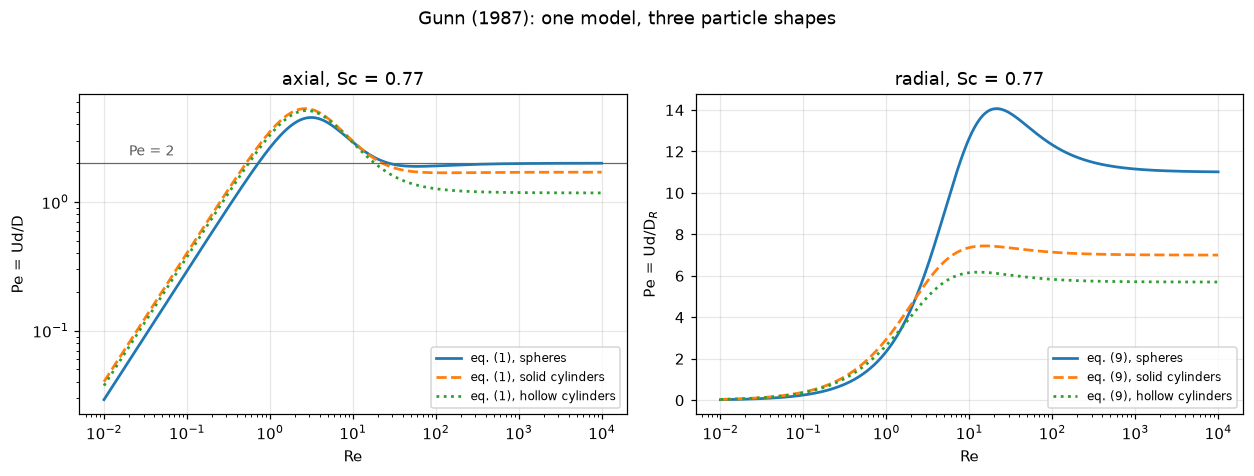

Pe_f (eqs 10-12) at Re -> 0 and Re -> infinity:
  spheres            40.00  ->   11.00
  solid cylinders    11.00  ->    7.00
  hollow cylinders    9.00  ->    5.70

D_axial / D_radial at Re = 1e+06, spheres: 5.500 - the textbook 5 to 6 falls out of two
correlations fitted to different experiments, neither of which was asked for that ratio

and the same beds carry two tortuosities: 1.4 in eq. (3) against 1.2 in eq. (10), a difference of +17%,
which the paper describes only as differing 'by small amounts'. Both are used here,
each in its own direction; swapping them is a break-table row.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
Re = np.logspace(-2, 4, 800)

for shape, style in zip(SHAPES, ("-", "--", ":")):
    ax[0].loglog(Re, Pe_axial(Re, SC_ARGON_AIR, eps=EPS_ASSUMED, shape=shape),
                 style, lw=1.8, label=f"eq. (1), {shape}")
    ax[1].semilogx(Re, Pe_radial(Re, SC_ARGON_AIR, eps=EPS_ASSUMED, shape=shape),
                   style, lw=1.8, label=f"eq. (9), {shape}")

ax[0].axhline(PE2, color="0.4", lw=0.8)
ax[0].annotate(f"Pe = {PE2:.0f}", (2e-2, PE2 * 1.15), color="0.35", fontsize=9)
for a, ttl, yl in zip(ax, ("axial", "radial"), ("Pe = Ud/D", "Pe = Ud/D$_R$")):
    a.set_xlabel("Re"); a.set_ylabel(yl)
    a.set_title(f"{ttl}, Sc = {SC_ARGON_AIR}")
    a.legend(fontsize=8, loc="lower right")
fig.suptitle("Gunn (1987): one model, three particle shapes", y=1.02)
fig.tight_layout(); plt.show()

RE_HI = 1e6
# eqs (10)-(12) run the OTHER way from eq. (3): exp(-7/Re) -> 1 at high Re, so
# Pe_f falls from its asymptote to (asymptote - amplitude).
print("Pe_f (eqs 10-12) at Re -> 0 and Re -> infinity:")
for s in SHAPES:
    print(f"  {s:17s} {float(Pe_f(1e-6, s)):6.2f}  ->  {float(Pe_f(RE_HI, s)):6.2f}")
D_RATIO_HI = (float(Pe_radial(RE_HI, SC_ARGON_AIR, eps=EPS_ASSUMED))
              / float(Pe_axial(RE_HI, SC_ARGON_AIR, eps=EPS_ASSUMED)))
print(f"\nD_axial / D_radial at Re = {RE_HI:.0g}, spheres: {D_RATIO_HI:.3f}"
      " - the textbook 5 to 6 falls out of two")
print("correlations fitted to different experiments, neither of which was asked "
      "for that ratio")

TAU_GAP = float(dev(G["tau_axial_spheres"], G["tau_radial_spheres"]))
print(f"\nand the same beds carry two tortuosities: {G['tau_axial_spheres']} in "
      f"eq. (3) against {G['tau_radial_spheres']} in eq. (10), a difference of "
      f"{TAU_GAP:+.0%},")
print("which the paper describes only as differing 'by small amounts'. Both are "
      "used here,")
print("each in its own direction; swapping them is a break-table row.")

### 2. The two coefficients in one bed

A correlation is not a model until something transports with it. The bed below is
Gunn's eq. (16) in two dimensions: his axial coefficient along $z$, his radial
coefficient along $r$, at one operating point. The operating point is chosen — the
paper has no reactor example — and it is printed in full so that nothing is
hidden.

In [9]:
RE_OP, DA_OP, L_OVER_D, DT_OVER_D = 50.0, 2.0, 100.0, 20.0
PE_AX = float(Pe_axial(RE_OP, SC_ARGON_AIR, eps=EPS_ASSUMED))
PE_R = float(Pe_radial(RE_OP, SC_ARGON_AIR, eps=EPS_ASSUMED))
K_OP = DA_OP / L_OVER_D           # U = 1, d = 1, L = 100 -> k L / U = 2

print(f"operating point: spheres, Re = {RE_OP:g}, Sc = {SC_ARGON_AIR}, "
      f"eps = {EPS_ASSUMED}")
print(f"  p(Re)   = {float(p_of_Re(RE_OP)):.5f}   (eq. 3)")
print(f"  Pe_ax   = {PE_AX:.5f}   ->  D   = U d / Pe_ax   (eq. 1)")
print(f"  Pe_f    = {float(Pe_f(RE_OP)):.5f}   (eq. 10)")
print(f"  Pe_r    = {PE_R:.5f}   ->  D_R = U d / Pe_r   (eq. 9)")
print(f"  D / D_R = {PE_R / PE_AX:.4f}")
print(f"  k L / U = {DA_OP:g},  L/d = {L_OVER_D:g},  d_t/d = {DT_OVER_D:g}"
      f"  (the paper requires d_t/d > {G['tube_to_particle_ratio_min']:.0f})")

operating point: spheres, Re = 50, Sc = 0.77, eps = 0.37
  p(Re)   = 0.37420   (eq. 3)
  Pe_ax   = 1.89204   ->  D   = U d / Pe_ax   (eq. 1)
  Pe_f    = 14.78861   (eq. 10)
  Pe_r    = 13.22257   ->  D_R = U d / Pe_r   (eq. 9)
  D / D_R = 6.9885
  k L / U = 2,  L/d = 100,  d_t/d = 20  (the paper requires d_t/d > 10)


### 3. What the wall channel costs, and what radial dispersion puts back

Gunn's eqs (7)–(8) argue that the high-porosity layer within $0.5d$ of the wall
does *not* carry a significantly faster interstitial velocity, because the
superficial ratio Price measured, 1.65, is mostly porosity. The argument is
qualitative — "suggesting that there may be no significant differences". A 2-D bed
turns it into a number, and it needs the radial coefficient to do it, because
radial dispersion is what erodes a wall channel once it exists.

Three velocity profiles are run: uniform; Gunn's corrected interstitial ratio; and
the ratio you get by reading Price's 1.65 as interstitial, which is the mistake his
eq. (8) exists to prevent. Each is run with the radial coefficient eq. (9) gives,
and again with radial dispersion switched off, so the two effects separate.

In [10]:
U_RATIO_GUNN = (G["superficial_velocity_ratio_price"] * G["voidage_bulk_spheres"]
                / G["voidage_wall_region"])
NO_RADIAL = 1e12          # Pe_r -> infinity is D_R -> 0
# read, not hard-coded: 'the wall region of extent 0.5d', journal page 368
WALL_EXTENT = G["wall_region_extent_diameters"]


def wall_run(ratio_w, pe_r, **kw):
    kw.setdefault("wall_extent", WALL_EXTENT)     # overridable, so it has a break row
    return Bed(PE_AX, pe_r, K_OP, L=L_OVER_D, d_t=DT_OVER_D, n_z=800, n_r=40,
               wall_ratio=ratio_w, **kw)


def wall_cost(ratio_w, pe_r, **kw):
    """Extra unconverted reactant at the outlet, against the uniform-profile bed
    run with the same settings.  Every break row on this metric goes through here."""
    return wall_run(ratio_w, pe_r, **kw).cup() / wall_run(1.0, pe_r, **kw).cup() - 1.0


runs = []
for label, ratio_w in [("uniform", 1.0),
                       ("Gunn eq. (8) interstitial ratio", U_RATIO_GUNN),
                       ("1.65 read as interstitial", G["superficial_velocity_ratio_price"])]:
    for rad_label, pe_r in [("eq. (9)", PE_R), ("none", NO_RADIAL)]:
        b = wall_run(ratio_w, pe_r)
        runs.append(dict(profile=label, radial=rad_label, U_w_over_U_b=ratio_w,
                         c_out=b.cup(), conversion=1 - b.cup()))
runs = pd.DataFrame(runs)
runs["unconverted_vs_uniform"] = dev(runs.c_out, runs.c_out.iloc[0])
print(runs.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

sel = lambda ratio_w, rad: float(runs[(np.isclose(runs.U_w_over_U_b, ratio_w))
                                      & (runs.radial == rad)]
                                 .unconverted_vs_uniform.iloc[0])
R165 = G["superficial_velocity_ratio_price"]
NAIVE_WITH = sel(R165, "eq. (9)")
NAIVE_WITHOUT = sel(R165, "none")
GUNN_WITH = sel(U_RATIO_GUNN, "eq. (9)")
HEAL = 1 - NAIVE_WITH / NAIVE_WITHOUT

# The Robin inlet is written with the AREA-MEAN velocity U (see the bc table).
# Writing the same balance with the local u(r) is the other defensible reading;
# it is measured here rather than argued about, and it is a break-table row.
NAIVE_WITH_LOCAL = wall_cost(R165, PE_R, local_inlet=True)
NAIVE_WITHOUT_LOCAL = wall_cost(R165, NO_RADIAL, local_inlet=True)

display(Markdown(rf"""
**Reading Price's {R165} as an interstitial ratio raises the unconverted reactant
leaving this bed by {NAIVE_WITHOUT:+.2%} with no radial mixing, and by
{NAIVE_WITH:+.2%} once eq. (9)'s radial coefficient is switched on** — so radial
dispersion erodes {HEAL:.0%} of the channel over this bed length. Gunn's corrected
ratio, {U_RATIO_GUNN:.4f}, moves the outlet by {GUNN_WITH:+.3%} with radial
dispersion and {sel(U_RATIO_GUNN, 'none'):+.3%} without it. **The whole of the
effect is in the difference between 1.65 and 1.02**, which is what eq. (8) is for;
at Gunn's corrected ratio the wall region is not worth putting in a model at all.

Three honest limits on that number. It is **one operating point**: the erosion
fraction depends on $L/d$, on $d_t/d$ and on the Damköhler group, and none of the
three is printed anywhere in the paper. The wall annulus here is a *step*, not
the smooth porosity profile a real bed has — the step is what the paper's own
"wall region of extent {WALL_EXTENT}$d$" describes, and no more; widening it is a
break-table row. And the Danckwerts inlet is written with the **area-mean**
velocity, $Uc - D\,\partial c/\partial z = Uc_0$, rather than with the local
$u(r)$: writing the same balance locally gives {NAIVE_WITH_LOCAL:+.2%} instead of
{NAIVE_WITH:+.2%} and {NAIVE_WITHOUT_LOCAL:+.2%} instead of {NAIVE_WITHOUT:+.2%},
so the erosion fraction moves from {HEAL:.1%} to
{1 - NAIVE_WITH_LOCAL / NAIVE_WITHOUT_LOCAL:.1%}. The choice is a modelling
convention the paper does not fix, it changes the answer by about
{abs(dev(NAIVE_WITH_LOCAL, NAIVE_WITH)):.0%} of itself, and no conclusion here
depends on it — which is why it is measured rather than argued.
"""))

                        profile  radial  U_w_over_U_b    c_out  conversion  unconverted_vs_uniform
                        uniform eq. (9)      1.000000 0.136905    0.863095                0.000000
                        uniform    none      1.000000 0.136905    0.863095               -0.000000
Gunn eq. (8) interstitial ratio eq. (9)      1.017500 0.136907    0.863093                0.000009
Gunn eq. (8) interstitial ratio    none      1.017500 0.136913    0.863087                0.000052
      1.65 read as interstitial eq. (9)      1.650000 0.138489    0.861511                0.011569
      1.65 read as interstitial    none      1.650000 0.144381    0.855619                0.054607



**Reading Price's 1.65 as an interstitial ratio raises the unconverted reactant
leaving this bed by +5.46% with no radial mixing, and by
+1.16% once eq. (9)'s radial coefficient is switched on** — so radial
dispersion erodes 79% of the channel over this bed length. Gunn's corrected
ratio, 1.0175, moves the outlet by +0.001% with radial
dispersion and +0.005% without it. **The whole of the
effect is in the difference between 1.65 and 1.02**, which is what eq. (8) is for;
at Gunn's corrected ratio the wall region is not worth putting in a model at all.

Three honest limits on that number. It is **one operating point**: the erosion
fraction depends on $L/d$, on $d_t/d$ and on the Damköhler group, and none of the
three is printed anywhere in the paper. The wall annulus here is a *step*, not
the smooth porosity profile a real bed has — the step is what the paper's own
"wall region of extent 0.5$d$" describes, and no more; widening it is a
break-table row. And the Danckwerts inlet is written with the **area-mean**
velocity, $Uc - D\,\partial c/\partial z = Uc_0$, rather than with the local
$u(r)$: writing the same balance locally gives +1.14% instead of
+1.16% and +5.48% instead of +5.46%,
so the erosion fraction moves from 78.8% to
79.1%. The choice is a modelling
convention the paper does not fix, it changes the answer by about
1% of itself, and no conclusion here
depends on it — which is why it is measured rather than argued.


## Validation

Ranked as the builder brief ranks them, best first. Route 1 is available here —
the paper contains a worked example with every input printed — and so is route 2,
four times over. The figure route is used **once**, through a dataset another page
already extracted and audited.

### V1. A worked example with printed intermediates: eq. (8)

$u_w/u_b = 1.65$, $e = 0.37$, $\bar e_w = 0.6$, all printed, and the answer
$U_w/U_b = 1.02$ printed too.

In [11]:
WALL_DEV = float(dev(U_RATIO_GUNN, G["interstitial_velocity_ratio_result"]))
eps_w_mean = 0.5 * (G["voidage_wall_range_min"] + G["voidage_wall_range_max"])
U_ratio_at = lambda e_w: (G["superficial_velocity_ratio_price"]
                          * G["voidage_bulk_spheres"] / e_w)

print(f"eq. (8): {G['superficial_velocity_ratio_price']} x "
      f"{G['voidage_bulk_spheres']} / {G['voidage_wall_region']} = {U_RATIO_GUNN:.5f}")
print(f"  printed {G['interstitial_velocity_ratio_result']}  ->  {WALL_DEV:+.3%}, "
      "which is what rounding to two decimals buys")
print(f"  the paper says e_w is LESS than the mean of {G['voidage_wall_range_min']} "
      f"and {G['voidage_wall_range_max']}; AT that mean ({eps_w_mean}) eq. (8) gives "
      f"{U_ratio_at(eps_w_mean):.4f} - the wall would be SLOWER than the bulk, which "
      "is why the paper picks a value below it")
print(f"  at e_w = 0.5 it gives {U_ratio_at(0.5):.4f} "
      f"({dev(U_ratio_at(0.5), U_RATIO_GUNN):+.1%}), so the check has real power "
      "against a mis-read wall porosity")

eq. (8): 1.65 x 0.37 / 0.6 = 1.01750
  printed 1.02  ->  -0.245%, which is what rounding to two decimals buys
  the paper says e_w is LESS than the mean of 0.37 and 1.0; AT that mean (0.685) eq. (8) gives 0.8912 - the wall would be SLOWER than the bulk, which is why the paper picks a value below it
  at e_w = 0.5 it gives 1.2210 (+20.0%), so the check has real power against a mis-read wall porosity


### V2. Internal identities

Four, none of which needs a figure or a solver.

**(a) The high-Re limit, by expansion and then by direct evaluation** — done above,
for all three shapes.

**(b) The low-ReSc limit against Edwards and Richardson's independently measured
tortuosity factor.** As $\mathrm{Re\,Sc}\to0$, eq. (1) gives
$D/(Ud)\to\varepsilon/(\tau\mathrm{Re\,Sc})$, i.e.
$\mathrm{Pe}\to\tau\mathrm{Re\,Sc}/\varepsilon$. E&R's eq. (18) gives
$\mathrm{Pe}\to\mathrm{Re}/0.38$, and their 0.38 is $\gamma\varepsilon/\mathrm{Sc}$,
so their limit is $\mathrm{Re\,Sc}/(\gamma\varepsilon)$. **The same expression, with
$\tau$ where they have $1/\gamma$ and $\varepsilon$ in the same place** — which is
both a check on two transcriptions made from different papers and the thing that
settles whether the two $\mathrm{Re}$'s and $\mathrm{Pe}$'s mean the same
quantities.

**(c) The same model as two different papers print it.** Gunn's 1993 note gives
eq. (42) with $\Gamma = 4(1-\varepsilon)\alpha_1^2/\varepsilon$. Substituting
$\Gamma$ turns it into eq. (1) term by term. The two transcriptions were made from
different documents, by different agents, three days apart, so agreement is
evidence about the *reading*. It is an algebraic identity and says nothing about
whether either reading is correct — and it has no break-table row, which is stated
below rather than hidden.

**(d) The closed form solves the equation.** Eq. (17) substituted back into
eq. (16), by finite differences on the printed expression itself, and checked
against the Danckwerts inlet it is supposed to satisfy.

In [12]:
# --- (b) the two molecular branches, side by side ------------------------
GAMMA_ER = E["tortuosity_factor_gamma"]
SC_ER = E["schmidt_number_used_in_eq18"]
A_ER = E["eq18_molecular_coefficient"]
TAU_G = G["tau_axial_spheres"]

RE_SMALL = 1e-4
slope_gunn = float(Pe_axial(RE_SMALL, SC_ARGON_AIR, eps=EPS_ASSUMED)) / RE_SMALL
slope_er = 1.0 / A_ER
TAU_VS_GAMMA = float(dev(1 / TAU_G, GAMMA_ER))
print("low-Re asymptote Pe/Re, from each paper's own printed constants")
print(f"  Gunn eq. (1):   tau Sc / eps  = {TAU_G} x {SC_ARGON_AIR} / {EPS_ASSUMED}"
      f" = {TAU_G * SC_ARGON_AIR / EPS_ASSUMED:.4f}"
      f"   (eq. 1 evaluated at Re = {RE_SMALL:g} gives {slope_gunn:.4f})")
print(f"  E&R  eq. (18):  1 / {A_ER}                = {slope_er:.4f}")
print(f"  ratio {slope_gunn / slope_er:.4f}, i.e. {dev(slope_gunn, slope_er):+.1%}")
print(f"  the two tortuosities: Gunn tau = {TAU_G} -> 1/tau = {1 / TAU_G:.4f} against "
      f"E&R's separately measured gamma = {GAMMA_ER}  ({TAU_VS_GAMMA:+.2%})")
print(f"  Schmidt group for argon-air: Gunn {SC_ARGON_AIR}, E&R {SC_ER} "
      f"({dev(SC_ARGON_AIR, SC_ER):+.1%}) - printed as they stand, not reconciled")
print("\n  Gunn's Notation (page 372) already settles this: Re = d U_0 rho / mu with")
print("  U_0 superficial, Pe = U d / D with U interstitial, which is exactly E&R's")
print("  pair. The two legs below were derived before that page was read and are")
print("  kept as corroboration. Both papers put eps in the same place in this")
print("  limit, and both assert Pe -> 2 at high Re, which is an absolute statement")
print("  and is not invariant under a rescaling of Pe. As a third leg: if")
print("  E&R's markers had to be divided by eps to reach Gunn's axes they would")
print(f"  peak at Pe = {fig9.peclet.max() / EPS_ASSUMED:.2f} at Re = "
      f"{fig9.reynolds[fig9.peclet.idxmax()] / EPS_ASSUMED:.2f}, where eq. (1) as")
print(f"  drawn on his own Figure 1 peaks below Pe = 5.")

# --- (c) 1987 eq. (1) against 1993 eq. (42) ------------------------------
Re_grid = np.logspace(-3, 4, 2001)
ID_DEV = max(float(np.max(np.abs(dev(D_over_Ud(Re_grid, Sc, eps=EPS_ASSUMED),
                                     D_over_Ud_1993(Re_grid, Sc, eps=EPS_ASSUMED)))))
             for Sc in (SC_ARGON_AIR, G["schmidt_liquid_fig1"]))
NAIVE_DEV = float(np.max(np.abs(dev(
    D_over_Ud(Re_grid, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED, stable=False),
    D_over_Ud(Re_grid, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED, stable=True)))))
print(f"\n(c) eq. (1) [1987] against eq. (42) [1993], both evaluated stably:"
      f" max relative difference {ID_DEV:.3e}")
print(f"    the SAME expression written with exp(x) - 1 instead of expm1(x) differs"
      f" by {NAIVE_DEV:.3e} at Sc = {G['schmidt_liquid_fig1']:.0f}"
      " - the identity is algebraic, the arithmetic is not")

# --- (d) eq. (17) put back into eq. (16) ---------------------------------
U_, D_, k_ = 1.0, 0.5, 0.02
lam_ = np.sqrt(U_ ** 2 / (4 * D_ ** 2) + k_ / D_) - U_ / (2 * D_)
c17 = lambda x: U_ / (U_ + D_ * lam_) * np.exp(-lam_ * x)
h = 1e-4
x = np.linspace(1.0, 20.0, 401)
res = (D_ * (c17(x + h) - 2 * c17(x) + c17(x - h)) / h ** 2
       - U_ * (c17(x + h) - c17(x - h)) / (2 * h) - k_ * c17(x))
EQ17_RESID = float(np.max(np.abs(res)) / np.max(np.abs(k_ * c17(x))))
inlet_resid = abs(U_ * 1.0 - (U_ * c17(0.0) + D_ * lam_ * c17(0.0)))
char_resid = abs(D_ * lam_ ** 2 + U_ * lam_ - k_) / k_
print(f"\n(d) eq. (17) substituted into eq. (16): worst residual {EQ17_RESID:.2e} of"
      f" the reaction term (central differences, h = {h:g}; the floor here is"
      " round-off, not truncation)")
print(f"    the same statement algebraically - lambda must solve D l^2 + U l - k = 0"
      f" - holds to {char_resid:.1e}, which is machine precision and is why it is"
      " NOT reported as a metric")
print(f"    and eq. (17) satisfies the Danckwerts inlet exactly:"
      f" |U c0 - (U c - D dc/dz)| = {inlet_resid:.2e} at x = 0")

low-Re asymptote Pe/Re, from each paper's own printed constants
  Gunn eq. (1):   tau Sc / eps  = 1.4 x 0.77 / 0.37 = 2.9135   (eq. 1 evaluated at Re = 0.0001 gives 2.9135)
  E&R  eq. (18):  1 / 0.38                = 2.6316
  ratio 1.1071, i.e. +10.7%
  the two tortuosities: Gunn tau = 1.4 -> 1/tau = 0.7143 against E&R's separately measured gamma = 0.73  (-2.15%)
  Schmidt group for argon-air: Gunn 0.77, E&R 0.72 (+6.9%) - printed as they stand, not reconciled

  Gunn's Notation (page 372) already settles this: Re = d U_0 rho / mu with
  U_0 superficial, Pe = U d / D with U interstitial, which is exactly E&R's
  pair. The two legs below were derived before that page was read and are
  kept as corroboration. Both papers put eps in the same place in this
  limit, and both assert Pe -> 2 at high Re, which is an absolute statement
  and is not invariant under a rescaling of Pe. As a third leg: if
  E&R's markers had to be divided by eps to reach Gunn's axes they would
  peak at Pe = 11.24 

### V3. Numbers the paper states in words

Seven, each of which can fail on a single mis-read digit, and none of which
involves reading a figure.

In [13]:
checks = []

RE_1000 = G["reynolds_of_high_re_asymptote"]
PE_1000 = float(Pe_axial(RE_1000, SC_ARGON_AIR, eps=EPS_ASSUMED))
checks.append(("Pe at Re = 1000, Sc = 0.77", PE_1000, G["peclet_high_re_asymptote"],
               "'Pe approaches the widely quoted value of 2'"))

p_lo = float(p_of_Re(G["reynolds_p_lower_plateau"]))
p_mid = float(p_of_Re(G["reynolds_p_transition_end"]))
p_hi = float(p_of_Re(G["reynolds_p_upper_plateau"]))
p_inf_sph = G["p_offset"] + G["p_amplitude_spheres"]
FRAC_1_200 = (p_mid - p_lo) / (p_inf_sph - p_lo)
checks.append(("p at Re = 1, against its Re -> 0 plateau", p_lo, G["p_offset"],
               "'constant values for p below Re = 1'"))
checks.append(("p at Re = 1000, against its Re -> inf plateau", p_hi, p_inf_sph,
               "'constant values for p ... above 1000'"))

ratio_lg = lambda R: float(D_over_Ud(R, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED)
                           / D_over_Ud(R, SC_ARGON_AIR, eps=EPS_ASSUMED))
opt = minimize_scalar(lambda t: -ratio_lg(np.exp(t)), bracket=(0.0, 1.2, 3.0))
RE_STAR, RATIO_STAR = float(np.exp(opt.x)), -float(opt.fun)
checks.append(("max liquid/gas ratio of D/(Ud)", RATIO_STAR, G["liquid_gas_max_factor"],
               "'a maximum difference of a factor of 10'"))
checks.append(("Re at that maximum", RE_STAR, G["liquid_gas_max_reynolds"], "'at Re ~ 3'"))

RE_CROSS = float(brentq(lambda R: ratio_lg(R) - 1.0, 0.05, 1.0))
checks.append(("Re where liquid D/(Ud) overtakes gas", RE_CROSS,
               G["liquid_gas_range_min"], "'within the range of 0.2 < Re < 300'"))

TAB1_DEV = float(dev(all_entries.mean(), G["intraparticle_diffusivity_fraction"]))
checks.append(("mean of Table 1's ten entries", float(all_entries.mean()),
               G["intraparticle_diffusivity_fraction"],
               "'about 10 % of molecular (Table 1)'"))

chk = pd.DataFrame(checks, columns=["quantity", "computed", "printed", "as printed"])
chk["dev"] = dev(chk.computed, chk.printed)
print(chk.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print(f"\nand the shape of p, which the paper describes rather than tabulates:")
print(f"  p(1) = {p_lo:.5f}, p(200) = {p_mid:.5f}, p(1000) = {p_hi:.5f}, "
      f"p(inf) = {p_inf_sph:.2f}")
print(f"  -> {FRAC_1_200:.1%} of p's total excursion happens between Re = 1 and 200,"
      " which is what")
print("     'the major change in p taking place from Re = 1 to 200' asserts")

RATIO_300 = ratio_lg(G["liquid_gas_range_max"])
Re_to_2 = float(brentq(lambda R: float(Pe_axial(R, SC_ARGON_AIR, eps=EPS_ASSUMED))
                       - (2 - 5e-4), 1e3, 1e7))
display(Markdown(rf"""
**Seven checks; the deviations run from {abs(chk.dev).min():.1%} to
{abs(chk.dev).max():.1%}, and every one is inside the precision of the phrase it
tests** — "approaches ... 2", "constant values for p below Re = 1" and "above
1000", "a factor of 10", "at Re ~ 3", "0.2", "about 10 %". None of these is
printed to more than two figures, so none of them could have been checked more
tightly than this; what they *can* do, and the break table shows they do, is fail
loudly on a mis-read digit.

The one statement that does *not* survive is the **upper** end of
"0.2 < Re < 300", and it fails for a structural reason rather than a numerical
one: it is not a crossing at all. The liquid/gas ratio of $D/(Ud)$ decays towards
1 asymptotically and is still **{RATIO_300:.3f}** at Re = {G['liquid_gas_range_max']:.0f}
and {ratio_lg(1000.0):.3f} at Re = 1000. Read as "the range over which the
difference matters", 300 is a judgement; read as a crossing it is wrong.

The Péclet limit is the interesting near-miss. Eq. (1) gives {PE_1000:.4f} at
Re = 1000, {abs(dev(PE_1000, 2.0)):.2%} below 2, and does not reach
{2 - 5e-4:.4f} until Re = {Re_to_2:.3g}. "Approaching 1000" is the right way to
say it, and a page that reported "2.000" here would be reporting the asymptote
rather than the equation.
"""))

                                     quantity  computed  printed                                   as printed     dev
                   Pe at Re = 1000, Sc = 0.77    1.9862   2.0000 'Pe approaches the widely quoted value of 2' -0.0069
     p at Re = 1, against its Re -> 0 plateau    0.1700   0.1700         'constant values for p below Re = 1'  0.0000
p at Re = 1000, against its Re -> inf plateau    0.4922   0.5000       'constant values for p ... above 1000' -0.0157
               max liquid/gas ratio of D/(Ud)   10.8909  10.0000     'a maximum difference of a factor of 10'  0.0891
                           Re at that maximum    3.1662   3.0000                                  'at Re ~ 3'  0.0554
         Re where liquid D/(Ud) overtakes gas    0.1771   0.2000         'within the range of 0.2 < Re < 300' -0.1143
                mean of Table 1's ten entries    0.0970   0.1000          'about 10 % of molecular (Table 1)' -0.0300

and the shape of p, which the paper describes rather th


**Seven checks; the deviations run from 0.0% to
11.4%, and every one is inside the precision of the phrase it
tests** — "approaches ... 2", "constant values for p below Re = 1" and "above
1000", "a factor of 10", "at Re ~ 3", "0.2", "about 10 %". None of these is
printed to more than two figures, so none of them could have been checked more
tightly than this; what they *can* do, and the break table shows they do, is fail
loudly on a mis-read digit.

The one statement that does *not* survive is the **upper** end of
"0.2 < Re < 300", and it fails for a structural reason rather than a numerical
one: it is not a crossing at all. The liquid/gas ratio of $D/(Ud)$ decays towards
1 asymptotically and is still **1.084** at Re = 300
and 1.025 at Re = 1000. Read as "the range over which the
difference matters", 300 is a judgement; read as a crossing it is wrong.

The Péclet limit is the interesting near-miss. Eq. (1) gives 1.9862 at
Re = 1000, 0.69% below 2, and does not reach
1.9995 until Re = 2.85e+04. "Approaching 1000" is the right way to
say it, and a page that reported "2.000" here would be reporting the asymptote
rather than the equation.


### V4. Against measurement: eq. (1) on the 55 markers `A2.5` digitised

Gunn's Figure 1 plots Edwards and Richardson's gas-phase points as one of its four
series, and asserts that eq. (1) with eq. (3) describes them. `A2.5` has those
measurements as a CSV, so the assertion is testable here without touching a figure.
Three things have to be said before the number is read.

**Are these markers inside Gunn's fit set? The printed evidence says probably
not.** This page originally assumed they were, and said so; reading what the two
papers actually print does not support it.

1. Gunn 1987, journal page 365: "values of the probability $p$ were estimated from
   dispersion experiments **in which the effect of molecular diffusion was very
   small** and given as a table showing the change with Reynolds number."
2. Gunn 1993, journal page 335, saying what that criterion meant: "when
   $\mathrm{Re\,Sc}\gg 1$, measurements of dispersion are not affected by molecular
   diffusion and therefore **experimental measurements of liquid-phase dispersion
   may be used to find the dependence of $p$ upon the Reynolds number** and this
   has been carried out for beds of spheres, solid cylinders and hollow cylinders
   [2, 5]. The experimental results for both gas-phase and liquid-phase dispersion
   may then be used **to compare** the predictions of eqn. (42) with experiment."
   Refs [2] and [5] are Gunn 1969 and Gunn 1987; Edwards and Richardson are [7],
   cited separately as one of the two gas-phase sets Figure 1 compares against.
3. **These markers fail that criterion.** They are gas phase at
   $\mathrm{Sc} = 0.77$; the cell below prints the $\mathrm{Re\,Sc}$ distribution,
   and it is nowhere near $\gg 1$.
4. Where the 1987 paper does name a fit set, it is not this one. Eqs (4) and (5)
   are "based upon the experimental results of England and Gunn (1970), for the
   dispersion of argon in beds of solid and hollow cylinders" (page 366); eq. (3)
   is attributed to nothing. The sentence that introduces all three — "a study of
   the experimental results for dispersion in beds of spheres, and in beds of
   cylinders shows that the dependence of $p$ upon Reynolds number may be expressed
   by the following equations" — names no dataset. Meanwhile the paper's own
   sentence about *these* points is the language of comparison: "the experimental
   estimates of Edwards and Richardson for (1968) the dispersion of argon in air
   are **well supported by** eq. (1)" (page 366).

So the honest label is **a comparison that is probably out of sample but not
provably held out** — closer to a test of eq. (1) than to a fit residual, and much
further from circular than `A2.5`'s own 11.75 %, where both constants were fitted
to exactly these 55 markers and nothing else. Nothing printed says these points
were held out either, so the page does not call the comparison a validation.

**What that changes.** If the 20.3 % is roughly out of sample, it is not the
flattered number a fit residual would be; it is what eq. (1) predicts for a gas
pair, at an assumed porosity, in a regime the correlation was *not* tuned on. Read
that way it is a respectable number for a one-function model — and the two things
that bound it are below: the null that a free constant $p$ achieves, and the
porosity nobody printed.

**The porosity is not printed, and it is the largest lever on the answer.** The
cell below runs the comparison at $\varepsilon$ = 0.34, 0.37 and 0.40 and at both
papers' Schmidt groups, and the spread across the porosity range is bigger than
anything else on the page.

**One shape, one gas pair, and a Reynolds range that stops at 50** where
$p(\mathrm{Re})$ is still climbing. The cell prints how much of $p$'s excursion
the dataset spans and what deleting $p(\mathrm{Re})$ altogether costs.

In [14]:
Re_d, Pe_d = fig9.reynolds.to_numpy(), fig9.peclet.to_numpy()

# Gunn's own stated criterion for the data p(Re) was estimated from: ReSc >> 1,
# "the effect of molecular diffusion very small". Where do these markers sit?
ReSc_d = Re_d * SC_ARGON_AIR
N_RESC_LT_10 = int(np.sum(ReSc_d < 10.0))
print(f"Gunn's fit criterion is ReSc >> 1. These 55 markers, at Sc = "
      f"{SC_ARGON_AIR}, run ReSc = {ReSc_d.min():.4f} to {ReSc_d.max():.1f},")
print(f"  median {np.median(ReSc_d):.2f}; {int(np.sum(ReSc_d < 1)):d} of {len(ReSc_d)} "
      f"below 1 and {N_RESC_LT_10:d} of {len(ReSc_d)} below 10.")
print("  Molecular diffusion is not 'very small' for them, so by Gunn's own stated")
print("  criterion they are unlikely to be in the set p(Re) was estimated from.")

# Recompute A2.5's own headline from the same file rather than quoting it.
Pe_eq18 = 1.0 / (E["eq18_molecular_coefficient"] / Re_d
                 + E["eq18_eddy_coefficient"]
                 / (1.0 + E["eq18_correction_coefficient"] / Re_d))
d_er = dev(Pe_eq18, Pe_d)
MAD_ER = float(np.mean(abs(d_er)))
print(f"E&R eq. (18) against these same 55 rows, recomputed here: "
      f"MAD {MAD_ER:.4%}, bias {np.mean(d_er):+.4%}")
print(f"  A2.5 publishes 11.75 % and +0.003 % for this comparison"
      f"  ->  reproduced to {abs(MAD_ER - 0.1175):.5f} and "
      f"{abs(np.mean(d_er) - 3.0e-5):.1e} absolute")

rows = []
for Sc, eps in [(SC_ARGON_AIR, EPS_ASSUMED), (SC_ER, EPS_ASSUMED),
                (SC_ARGON_AIR, 0.34), (SC_ARGON_AIR, 0.40)]:
    d = dev(Pe_axial(Re_d, Sc, eps=eps), Pe_d)
    rows.append(dict(Sc=Sc, eps=eps, MAD=np.mean(abs(d)), median=np.median(abs(d)),
                     bias=np.mean(d), log_scatter=np.std(np.log(1 + d))))
gunn_fit = pd.DataFrame(rows)
print("\neq. (1) with eq. (3) against the same 55 rows:")
print(gunn_fit.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
MAD_G, BIAS_G = float(gunn_fit.MAD[0]), float(gunn_fit.bias[0])
EPS_SENS = (float(gunn_fit.MAD[2]), float(gunn_fit.MAD[3]))
EPS_SPREAD = abs(EPS_SENS[1] - EPS_SENS[0])
SC_COST = abs(float(gunn_fit.MAD[1]) - MAD_G)

nulls = {}
for lab, kw in [("p frozen at 0.17, its low-Re plateau",
                 dict(p=np.full_like(Re_d, G["p_offset"]))),
                ("p frozen at 0.50, its high-Re plateau",
                 dict(p=np.full_like(Re_d, p_inf_sph))),
                ("eq. (1) without its second term", dict(keep_exp_term=False))]:
    nulls[lab] = float(np.mean(abs(dev(
        Pe_axial(Re_d, SC_ARGON_AIR, eps=EPS_ASSUMED, **kw), Pe_d))))
nulls["E&R eq. (15): no radial-mixing correction"] = float(np.mean(abs(dev(
    1.0 / (E["eq18_molecular_coefficient"] / Re_d + E["eq18_eddy_coefficient"]),
    Pe_d))))

# The STRONGEST null for "delete p(Re)" is not p frozen at a printed plateau, it
# is a FREE constant p. Anything weaker flatters p(Re).
mad_const_p = lambda pp, eps: float(np.mean(abs(dev(
    Pe_axial(Re_d, SC_ARGON_AIR, eps=eps, p=np.full_like(Re_d, pp)), Pe_d))))
opt_p = minimize_scalar(lambda pp: mad_const_p(pp, EPS_ASSUMED), bounds=(0.01, 0.95),
                        method="bounded", options={"xatol": 1e-10})
P_FREE, NULL_FREE = float(opt_p.x), float(opt_p.fun)
nulls["p a FREE constant (the strongest null)"] = NULL_FREE
P_COST = NULL_FREE - MAD_G
P_COST_PLATEAU = nulls["p frozen at 0.17, its low-Re plateau"] - MAD_G
print("\nnulls, mean absolute deviation on the same rows:")
for k, v in nulls.items():
    print(f"  {k:44s} {v:8.2%}")
print(f"  the free constant is p = {P_FREE:.4f}, so at eps = {EPS_ASSUMED} deleting "
      f"p(Re) costs {P_COST * 100:.1f} points against the strongest null, not the "
      f"{P_COST_PLATEAU * 100:.1f} a frozen plateau suggests")

# --- the porosity sweep: NOT monotone, and the two models prefer different eps ---
mad_at = lambda e: float(np.mean(abs(dev(Pe_axial(Re_d, SC_ARGON_AIR, eps=e), Pe_d))))
best_const_at = lambda e: minimize_scalar(lambda pp: mad_const_p(pp, e),
                                          bounds=(0.01, 0.95), method="bounded",
                                          options={"xatol": 1e-10})
sweep = pd.DataFrame({"eps": np.round(np.arange(0.34, 0.521, 0.02), 3)})
sweep["MAD"] = [mad_at(e) for e in sweep.eps]
opt_e = minimize_scalar(mad_at, bounds=(0.28, 0.58), method="bounded",
                        options={"xatol": 1e-9})
EPS_BEST, MAD_BEST = float(opt_e.x), float(opt_e.fun)
opt_e2 = minimize_scalar(lambda e: best_const_at(e).fun, bounds=(0.28, 0.58),
                         method="bounded", options={"xatol": 1e-7})
EPS_BEST_NULL, NULL_BEST = float(opt_e2.x), float(opt_e2.fun)
P_FREE_BEST = float(best_const_at(EPS_BEST_NULL).x)
P_COST_BEST = NULL_BEST - MAD_BEST
print("\nthe residual is NOT monotone in eps - it has an interior minimum:")
print("  " + "  ".join(f"{e:.2f}" for e in sweep.eps))
print("  " + "  ".join(f"{m:.3f}" for m in sweep.MAD))
print(f"  eq. (1) + eq. (3) is best at eps = {EPS_BEST:.4f}, MAD {MAD_BEST:.2%}"
      f"  (against {MAD_G:.2%} at the assumed {EPS_ASSUMED})")
print(f"  eq. (1) with a free constant p is best at eps = {EPS_BEST_NULL:.4f}, "
      f"p = {P_FREE_BEST:.4f}, MAD {NULL_BEST:.2%}")
print(f"  so p(Re) clears its strongest null by {P_COST * 100:.1f} points at "
      f"eps = {EPS_ASSUMED} and by {P_COST_BEST * 100:.1f} points when each model")
print("  is given the porosity it prefers - the margin is porosity-dependent")

P_SPAN = ((float(p_of_Re(Re_d.max())) - float(p_of_Re(Re_d.min())))
          / (p_inf_sph - G["p_offset"]))
print(f"\nover Re = {Re_d.min():.5f} to {Re_d.max():.3g}, p moves from "
      f"{float(p_of_Re(Re_d.min())):.4f} to {float(p_of_Re(Re_d.max())):.4f}"
      f" - {P_SPAN:.1%} of its total excursion")

# the +/- 5 px systematic A2.5 carries, propagated into THIS page's headline
PX_PER_DEC_PE = 604.56          # from A2.5's sidecar calibration
for shift in (-5.0, 5.0):
    d = dev(Pe_axial(Re_d, SC_ARGON_AIR, eps=EPS_ASSUMED),
            Pe_d * 10 ** (shift / PX_PER_DEC_PE))
    print(f"  every marker shifted {shift:+.0f} px in Pe: MAD {np.mean(abs(d)):.2%},"
          f" bias {np.mean(d):+.2%}")

# and the one marker A2.5 leaves to the maintainer (its sidecar gives Re, Pe)
Re_aug, Pe_aug = np.append(Re_d, 1.76), np.append(Pe_d, 2.77)
d = dev(Pe_axial(Re_aug, SC_ARGON_AIR, eps=EPS_ASSUMED), Pe_aug)
print(f"  including the one nearly-resolvable fused glyph (Re 1.76, Pe 2.77, from"
      f" A2.5's sidecar): MAD {np.mean(abs(d)):.2%} against {MAD_G:.2%}")

# where eq. (1) peaks, beside where E&R's own fit peaks
opt2 = minimize_scalar(lambda t: -float(Pe_axial(np.exp(t), SC_ARGON_AIR,
                                                 eps=EPS_ASSUMED)),
                       bracket=(0.0, 1.2, 3.0))
RE_PEAK, PE_PEAK = float(np.exp(opt2.x)), -float(opt2.fun)
opt3 = minimize_scalar(
    lambda t: -1.0 / (E["eq18_molecular_coefficient"] / np.exp(t)
                      + E["eq18_eddy_coefficient"]
                      / (1.0 + E["eq18_correction_coefficient"] / np.exp(t))),
    bracket=(0.0, 1.2, 3.0))
RE_PEAK_ER, PE_PEAK_ER = float(np.exp(opt3.x)), -float(opt3.fun)
print(f"\nmaximum of eq. (1):       Pe = {PE_PEAK:.4f} at Re = {RE_PEAK:.4f}")
print(f"maximum of E&R's eq. (18): Pe = {PE_PEAK_ER:.4f} at Re = {RE_PEAK_ER:.4f}"
      "  (recomputed from A2.5's own")
print(f"  printed constants; A2.5 publishes Pe = 3.186 at Re = 3.195, so this "
      f"reproduces to {abs(PE_PEAK_ER - 3.186):.4f} and {abs(RE_PEAK_ER - 3.195):.4f})")
print(f"largest measured Pe in the file: {Pe_d.max():.4f} at Re = "
      f"{Re_d[Pe_d.argmax()]:.4f}")
print("A2.5 records Gunn's own 'maximum at Re about 4' as being for his Figure 1's")
print("COMBINED gas-phase set - Gunn & Pryce's data together with E&R's - not for")
print("E&R's points alone, and this page repeats that attribution rather than the "
      "gloss.")

Gunn's fit criterion is ReSc >> 1. These 55 markers, at Sc = 0.77, run ReSc = 0.0066 to 37.8,
  median 1.40; 26 of 55 below 1 and 47 of 55 below 10.
  Molecular diffusion is not 'very small' for them, so by Gunn's own stated
  criterion they are unlikely to be in the set p(Re) was estimated from.
E&R eq. (18) against these same 55 rows, recomputed here: MAD 11.7495%, bias +0.0031%
  A2.5 publishes 11.75 % and +0.003 % for this comparison  ->  reproduced to 0.00001 and 7.6e-07 absolute

eq. (1) with eq. (3) against the same 55 rows:
    Sc    eps    MAD  median   bias  log_scatter
0.7700 0.3700 0.2030  0.1492 0.1577       0.1994
0.7200 0.3700 0.1974  0.1273 0.1368       0.2052
0.7700 0.3400 0.2662  0.1925 0.2383       0.2040
0.7700 0.4000 0.1755  0.1052 0.0863       0.1964

nulls, mean absolute deviation on the same rows:
  p frozen at 0.17, its low-Re plateau           24.88%
  p frozen at 0.50, its high-Re plateau          67.63%
  eq. (1) without its second term                23.16%

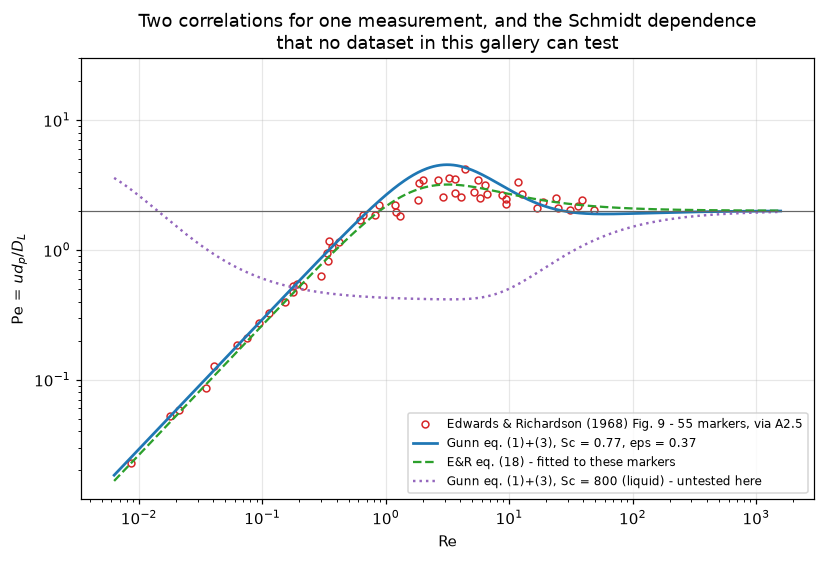


**Gunn's correlation sits +15.8% high on Edwards and Richardson's points,
with a mean absolute deviation of 20.3%, against 11.75% for their own
two-constant fit.** That ordering is the expected one and is not a finding: E&R
fitted $\gamma$ and $\beta$ to exactly these markers, while by Gunn's own stated
criterion — $\mathrm{Re\,Sc}\gg1$, and 47 of these 55 markers
are below $\mathrm{Re\,Sc} = 10$ — these points are unlikely to be in the set he
estimated $p(\mathrm{Re})$ from at all.

What the comparison does establish is a ceiling, a floor, and one uncomfortable
fact about which of them the data can resolve.

*The ceiling.* Something Reynolds-dependent has to be in the model. Freezing $p$
at 0.50 — which is what the mixing-cell picture behind $\mathrm{Pe} = 2$ amounts
to — costs 68%, and E&R's own
uncorrected eq. (15) costs
30%. Both are far worse than
20%.

*The floor, measured against the strongest null available.* Over
Re = 0.00857 to 49.1, $p$ moves through 61% of its
excursion — so these data do exercise $p(\mathrm{Re})$. The right null is not $p$
frozen at a printed plateau (24.9%);
it is a **free** constant $p$, which does better at
22.96% with $p$ = 0.0793. Against that, **deleting
$p(\mathrm{Re})$ costs 2.7 percentage points at
$\varepsilon$ = 0.37** — and 4.6 points when each model
is given the porosity it prefers (16.38% at
$\varepsilon$ = 0.443 against 21.01% at
$\varepsilon$ = 0.433). So the margin by which $p(\mathrm{Re})$
beats a constant is itself a function of the porosity nobody printed, which is the
sharpest form of this page's central caveat.

*And the unprinted porosity swamps both.* The comparison gives 26.6% at
$\varepsilon$ = 0.34 and 17.5% at 0.40, a spread of
9.1 percentage points — **3.4 times the
cost of deleting $p(\mathrm{Re})$** at that porosity, against the
0.6 points that separate Gunn's Schmidt group for argon–air from
Edwards and Richardson's, and larger than the ±5 px digitisation systematic. The
residual does **not** fall monotonically: it has an interior minimum at
$\varepsilon$ = 0.443 (16.4%), a looser bed than the
0.37 Gunn quotes for the bulk, and it rises again above that. With the
porosity unprinted, nothing here can separate a porosity error from a model error,
and the page does not try.


In [15]:
fig, ax = plt.subplots(figsize=(7.6, 5.2))
Re = np.logspace(-2.2, 3.2, 600)
ax.loglog(Re_d, Pe_d, "o", ms=4.5, mfc="none", color="C3",
          label=f"Edwards & Richardson (1968) Fig. 9 - {len(Re_d)} markers, via A2.5")
ax.loglog(Re, Pe_axial(Re, SC_ARGON_AIR, eps=EPS_ASSUMED), "-", lw=1.8, color="C0",
          label=f"Gunn eq. (1)+(3), Sc = {SC_ARGON_AIR}, eps = {EPS_ASSUMED}")
ax.loglog(Re, 1.0 / (E["eq18_molecular_coefficient"] / Re + E["eq18_eddy_coefficient"]
                     / (1.0 + E["eq18_correction_coefficient"] / Re)), "--", lw=1.5,
          color="C2", label="E&R eq. (18) - fitted to these markers")
ax.loglog(Re, Pe_axial(Re, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED), ":", lw=1.6,
          color="C4",
          label=f"Gunn eq. (1)+(3), Sc = {G['schmidt_liquid_fig1']:.0f} (liquid) - untested here")
ax.axhline(2.0, color="0.4", lw=0.8)
ax.set_xlabel("Re"); ax.set_ylabel("Pe = $u d_p / D_L$")
ax.set_title("Two correlations for one measurement, and the Schmidt dependence\n"
             "that no dataset in this gallery can test")
ax.set_ylim(1.2e-2, 3e1)
ax.legend(fontsize=8, loc="lower right"); fig.tight_layout(); plt.show()

display(Markdown(rf"""
**Gunn's correlation sits {BIAS_G:+.1%} high on Edwards and Richardson's points,
with a mean absolute deviation of {MAD_G:.1%}, against {MAD_ER:.2%} for their own
two-constant fit.** That ordering is the expected one and is not a finding: E&R
fitted $\gamma$ and $\beta$ to exactly these markers, while by Gunn's own stated
criterion — $\mathrm{{Re\,Sc}}\gg1$, and {N_RESC_LT_10} of these {len(Re_d)} markers
are below $\mathrm{{Re\,Sc}} = 10$ — these points are unlikely to be in the set he
estimated $p(\mathrm{{Re}})$ from at all.

What the comparison does establish is a ceiling, a floor, and one uncomfortable
fact about which of them the data can resolve.

*The ceiling.* Something Reynolds-dependent has to be in the model. Freezing $p$
at 0.50 — which is what the mixing-cell picture behind $\mathrm{{Pe}} = 2$ amounts
to — costs {nulls['p frozen at 0.50, its high-Re plateau']:.0%}, and E&R's own
uncorrected eq. (15) costs
{nulls['E&R eq. (15): no radial-mixing correction']:.0%}. Both are far worse than
{MAD_G:.0%}.

*The floor, measured against the strongest null available.* Over
Re = {Re_d.min():.3g} to {Re_d.max():.3g}, $p$ moves through {P_SPAN:.0%} of its
excursion — so these data do exercise $p(\mathrm{{Re}})$. The right null is not $p$
frozen at a printed plateau ({nulls['p frozen at 0.17, its low-Re plateau']:.1%});
it is a **free** constant $p$, which does better at
{NULL_FREE:.2%} with $p$ = {P_FREE:.4f}. Against that, **deleting
$p(\mathrm{{Re}})$ costs {P_COST * 100:.1f} percentage points at
$\varepsilon$ = {EPS_ASSUMED}** — and {P_COST_BEST * 100:.1f} points when each model
is given the porosity it prefers ({MAD_BEST:.2%} at
$\varepsilon$ = {EPS_BEST:.3f} against {NULL_BEST:.2%} at
$\varepsilon$ = {EPS_BEST_NULL:.3f}). So the margin by which $p(\mathrm{{Re}})$
beats a constant is itself a function of the porosity nobody printed, which is the
sharpest form of this page's central caveat.

*And the unprinted porosity swamps both.* The comparison gives {EPS_SENS[0]:.1%} at
$\varepsilon$ = 0.34 and {EPS_SENS[1]:.1%} at 0.40, a spread of
{EPS_SPREAD * 100:.1f} percentage points — **{EPS_SPREAD / P_COST:.1f} times the
cost of deleting $p(\mathrm{{Re}})$** at that porosity, against the
{SC_COST * 100:.1f} points that separate Gunn's Schmidt group for argon–air from
Edwards and Richardson's, and larger than the ±5 px digitisation systematic. The
residual does **not** fall monotonically: it has an interior minimum at
$\varepsilon$ = {EPS_BEST:.3f} ({MAD_BEST:.1%}), a looser bed than the
{EPS_ASSUMED} Gunn quotes for the bulk, and it rises again above that. With the
porosity unprinted, nothing here can separate a porosity error from a model error,
and the page does not try.
"""))

### V5. The solver: two closed forms, and what each one cannot see

**V5a — eq. (17), the paper's own.** With a flat inlet the 2-D bed has no radial
gradient, so the radial operator annihilates the solution and the area-mean profile
must be eq. (17) exactly. That is a real check on the axial discretisation and on
the two axial boundary conditions — and it is **structurally blind to everything
radial**. It cannot see `nu=0`, it cannot see a wrong $D_R$, it cannot see a
five-cell radial grid.

**V5b — a 2-D closed form, which can see them.** Feed the bed the first zero-flux
radial mode, $c_0(r) = J_0(\beta_1 r/R)$ with $J_1(\beta_1)=0$. The mode is an
eigenfunction of the radial operator, so the exact solution is eq. (17) again with
$k \to k + D_R(\beta_1/R)^2$ — a generalisation Gunn does not print, derived here,
and one that reads $D_R$, the geometry factor `nu` and the radial grid. Between
them the two checks cover both axes; the break table measures which covers what
instead of asserting it.

In [16]:
def conv_study(inlet_mode, grids, **kw):
    out = []
    for n_z, n_r in grids:
        b = Bed(PE_AX, PE_R, K_OP, L=L_OVER_D, d_t=DT_OVER_D,
                n_z=n_z, n_r=n_r, inlet_mode=inlet_mode, **kw)
        ex = b.closed_form()
        out.append(dict(n_z=n_z, n_r=n_r,
                        sup_error=float(np.max(np.abs(b.c - ex)) / np.max(np.abs(ex))),
                        iters=b.iters, resid=b.resid))
    df = pd.DataFrame(out)
    df["order"] = np.r_[np.nan, np.log2(df.sup_error.values[:-1]
                                        / df.sup_error.values[1:])]
    return df


flat = conv_study(0, [(100, 20), (200, 20), (400, 20), (800, 20)])
bess = conv_study(1, [(100, 10), (200, 20), (400, 40), (800, 80)])
print("V5a  flat inlet against eq. (17) - refining z only")
print(flat.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\nV5b  Bessel-mode inlet against the 2-D closed form - refining both axes")
print(bess.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

EQ17_ERR = float(flat.sup_error.iloc[-1])
BESSEL_ERR = float(bess.sup_error.iloc[-1])
print(f"\nevery deferred correction asserted its own convergence: worst iteration"
      f" count {int(max(flat.iters.max(), bess.iters.max()))} of a cap of 60,"
      f" worst final residual {max(flat.resid.max(), bess.resid.max()):.1e}")

V5a  flat inlet against eq. (17) - refining z only
 n_z  n_r  sup_error  iters     resid  order
 100   20  4.486e-05     18 9.217e-13    NaN
 200   20  1.163e-05     15 2.564e-13  1.948
 400   20   2.96e-06     11 5.791e-13  1.974
 800   20  7.454e-07      9 1.464e-13   1.99

V5b  Bessel-mode inlet against the 2-D closed form - refining both axes
 n_z  n_r  sup_error  iters     resid  order
 100   10   0.001874     19 3.828e-13    NaN
 200   20  0.0004657     15  3.88e-13  2.008
 400   40   0.000116     11 8.884e-13  2.005
 800   80  2.896e-05      9 2.253e-13  2.003

every deferred correction asserted its own convergence: worst iteration count 19 of a cap of 60, worst final residual 9.2e-13


### V6. Break table

Every metric this page reports needs a row that moves it. Two families of metric
live on this page — solver identities and correlation results — and they fail
under disjoint defects, so both tables are needed and neither substitutes for the
other.

In [17]:
REF = dict(L=L_OVER_D, d_t=DT_OVER_D, n_z=800, n_r=80)
b_ref = Bed(PE_AX, PE_R, K_OP, inlet_mode=1, **REF)


def sup_err(inlet_mode, **kw):
    kws = dict(REF)
    if inlet_mode == 0:
        kws["n_r"] = 20
    kws.update(kw)
    b = Bed(PE_AX, PE_R, K_OP, inlet_mode=inlet_mode, **kws)
    ex = b.closed_form()
    return float(np.max(np.abs(b.c - ex)) / np.max(np.abs(ex)))


BASE_F, BASE_B = sup_err(0), sup_err(1)
defects = [
    ("baseline", {}),
    ("nu = 0 on the radial divergence", dict(nu_r=0)),
    ("outlet eq. (18) -> zero gradient", dict(outlet="danckwerts")),
    ("inlet Danckwerts -> Dirichlet", dict(inlet="dirichlet")),
    ("no TVD (bare first-order upwind)", dict(limiter=None)),
    ("radial grid n_r = 5", dict(n_r=5)),
    # rows 6 and 7 change the coefficient CONSISTENTLY - operator, lam, k_eff and
    # closed_form() all move together, which is why they barely register.
    ("D_R +10 %, operator AND closed form", dict(DR_op=b_ref.DR * 1.1)),
    ("D +10 %, operator AND closed form", dict(D_op=b_ref.D * 1.1)),
    # rows 8 and 9 are the genuine article: the operator is built with 1.1x the
    # coefficient and the reference is held at the unperturbed value.
    ("D_R +10 % in the OPERATOR ONLY", dict(DR_disc=b_ref.DR * 1.1)),
    ("D +10 % in the OPERATOR ONLY", dict(D_disc=b_ref.D * 1.1)),
]
sb = pd.DataFrame([dict(defect=lab, V5a=sup_err(0, **kw), V5b=sup_err(1, **kw))
                   for lab, kw in defects])
sb["x V5a"] = sb.V5a / BASE_F
sb["x V5b"] = sb.V5b / BASE_B
print(sb.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

                             defect       V5a       V5b     x V5a  x V5b
                           baseline 7.454e-07 2.896e-05         1      1
    nu = 0 on the radial divergence 7.454e-07   0.07662         1   2646
   outlet eq. (18) -> zero gradient   0.00127 0.0006738      1704  23.27
      inlet Danckwerts -> Dirichlet   0.01046   0.01618 1.403e+04  558.7
   no TVD (bare first-order upwind)  0.001208  0.001843      1621  63.65
                radial grid n_r = 5 7.454e-07  0.007284         1  251.5
D_R +10 %, operator AND closed form 7.454e-07 3.079e-05         1  1.063
  D +10 %, operator AND closed form 7.425e-07 2.896e-05    0.9961      1
     D_R +10 % in the OPERATOR ONLY 7.454e-07    0.0129         1  445.3
       D +10 % in the OPERATOR ONLY  0.001021  0.001556      1369  53.74


In [18]:
# A mis-transcribed constant moves NO solver residual. It needs its own rows.
pe_limit_of = lambda amp: 2 * (G["p_offset"] + amp) / (1 - G["p_offset"] - amp)
mad_with = lambda **kw: float(np.mean(abs(dev(
    Pe_axial(Re_d, SC_ARGON_AIR, **{"eps": EPS_ASSUMED, **kw}), Pe_d))))

corr = pd.DataFrame([
    dict(metric="Pe limit, spheres",
         published=pe_limit_of(G["p_amplitude_spheres"]),
         broken=pe_limit_of(G["p_amplitude_solid_cylinders"]),
         defect="eq. (3)'s 0.33 mis-read as eq. (4)'s 0.29"),
    dict(metric="Pe limit, spheres",
         published=pe_limit_of(G["p_amplitude_spheres"]),
         broken=pe_limit_of(0.30),
         defect="0.33 mis-read as 0.30"),
    dict(metric="U_w/U_b from eq. (8)",
         published=U_RATIO_GUNN, broken=U_ratio_at(0.5),
         defect="wall porosity 0.6 mis-read as 0.5"),
    dict(metric="max liquid/gas ratio",
         published=RATIO_STAR,
         broken=float(D_over_Ud(RE_STAR, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED,
                                alpha1=BETA1)
                      / D_over_Ud(RE_STAR, SC_ARGON_AIR, eps=EPS_ASSUMED,
                                  alpha1=BETA1)),
         defect="alpha_1 taken as the first root of J_1, not J_0"),
    dict(metric="Pe at Re = 1000",
         published=PE_1000,
         broken=float(Pe_axial(RE_1000, SC_ARGON_AIR, eps=EPS_ASSUMED,
                               p=p_of_Re(RE_1000, scale=2.4))),
         defect="eq. (3)'s 24 mis-read as 2.4"),
    dict(metric="eq. (1) vs the 55 markers, MAD",
         published=MAD_G, broken=mad_with(eps=0.50),
         defect="porosity 0.37 taken as 0.50"),
    dict(metric="eq. (1) vs the 55 markers, MAD",
         published=MAD_G, broken=mad_with(alpha1=BETA1),
         defect="alpha_1 taken as the first root of J_1"),
    dict(metric="eq. (1) vs the 55 markers, MAD",
         published=MAD_G, broken=mad_with(tau=1.2),
         defect="the radial tortuosity 1.2 used for the axial branch"),
    dict(metric="Pe limit, spheres",
         published=pe_limit_of(G["p_amplitude_spheres"]),
         broken=2 * (0.11 + G["p_amplitude_spheres"]) / (1 - 0.11
                                                         - G["p_amplitude_spheres"]),
         defect="p_offset 0.17 mis-read as 0.11 (the text layer renders it 'O.i7')"),
    dict(metric="wall-channel cost, eq. (9) radial",
         published=NAIVE_WITH, broken=NAIVE_WITHOUT,
         defect="radial dispersion switched off"),
    dict(metric="wall-channel cost, eq. (9) radial",
         published=NAIVE_WITH,
         broken=wall_cost(R165, PE_R, wall_extent=2 * WALL_EXTENT),
         defect=f"wall region {WALL_EXTENT}d mis-read as {2 * WALL_EXTENT}d"),
    dict(metric="wall-channel cost, eq. (9) radial",
         published=NAIVE_WITH, broken=NAIVE_WITH_LOCAL,
         defect="Danckwerts inlet written with the local u(r), not the area mean"),
    dict(metric="Table 1 mean vs 'about 10 %'",
         published=float(all_entries.mean()),
         broken=float(np.nan_to_num(vals).mean()),
         defect="the two printed em dashes read as zeros"),
    dict(metric="Table 1 worst row spread",
         published=float(row_spread.max()),
         broken=float(np.nanmax(np.nan_to_num(vals, nan=np.nan)[0]) / 0.0075 - 1),
         defect="SA201's 0.075 mis-read as 0.0075"),
    dict(metric="eq. (1) high-Re limit vs 2p/(1-p)",
         published=float(np.max(np.abs(limits.rel_dev))),
         broken=float(np.max(np.abs(dev(
             [float(Pe_axial(RE_BIG, SC_ARGON_AIR, eps=EPS_ASSUMED, shape=s,
                             keep_exp_term=False)) for s in limits["shape"]],
             limits.Pe_limit)))),
         defect="eq. (1)'s second term dropped"),
    dict(metric="Re where liquid overtakes gas",
         published=RE_CROSS,
         broken=float(brentq(lambda R: float(
             D_over_Ud(R, G["schmidt_liquid_fig1"], eps=EPS_ASSUMED, alpha1=BETA1)
             / D_over_Ud(R, SC_ARGON_AIR, eps=EPS_ASSUMED, alpha1=BETA1)) - 1.0,
             0.02, 1.0)),
         defect="alpha_1 taken as the first root of J_1"),
    dict(metric="1/tau vs E&R's gamma",
         published=1 / TAU_G, broken=1 / G["tau_radial_spheres"],
         defect="eq. (10)'s radial tau = 1.2 used in eq. (3)'s place"),
    dict(metric="maximum of eq. (1), Pe",
         published=PE_PEAK,
         broken=-float(minimize_scalar(
             lambda t: -float(Pe_axial(np.exp(t), SC_ARGON_AIR, eps=EPS_ASSUMED,
                                       alpha1=BETA1)),
             bracket=(0.0, 1.2, 3.0)).fun),
         defect="alpha_1 taken as the first root of J_1"),
    dict(metric="D_axial/D_radial at high Re",
         published=D_RATIO_HI,
         broken=float(Pe_radial(RE_HI, SC_ARGON_AIR, eps=EPS_ASSUMED,
                                amplitude=2.9))
                / float(Pe_axial(RE_HI, SC_ARGON_AIR, eps=EPS_ASSUMED)),
         defect="eq. (10)'s 29 mis-read as 2.9"),
    dict(metric="fraction of p's excursion sampled",
         published=P_SPAN,
         broken=float((p_of_Re(Re_d.max(), scale=2.4) - p_of_Re(Re_d.min(), scale=2.4))
                      / G["p_amplitude_spheres"]),
         defect="eq. (3)'s 24 mis-read as 2.4"),
])
corr["move"] = dev(corr.broken, corr.published)
print(corr.to_string(index=False, float_format=lambda v: f"{v:.5g}"))

display(Markdown(rf"""
**Read the two tables together, because each is blind where the other sees.**

The solver identities move by factors of {sb['x V5b'][1]:.0f},
{sb['x V5b'][2]:.0f} and {sb['x V5b'][5]:.0f} for a wrong geometry factor, a wrong
outlet condition and a five-cell radial grid, and by {sb['x V5a'][3]:.0f} on V5a for
a Dirichlet inlet.

**The four coefficient rows are two different experiments and they say opposite
things.** Rows 6 and 7 change $D_R$ or $D$ by 10 % *consistently* — in the
operator, in $\lambda$, in $k_\mathrm{{eff}}$ and in `closed_form()` — and move the
residuals by {abs(sb['x V5b'][6] - 1):.1%} and {abs(sb['x V5b'][7] - 1):.1%}. That
is the honest limit of these checks: **a transport coefficient that is wrong
*everywhere* is invisible to both**, because the closed form they are compared
against is built from the same numbers. Nobody should read {BESSEL_ERR:.1e} as
evidence that $D$ or $D_R$ is right.

Rows 8 and 9 inject the same 10 % into the **operator alone**, holding the
reference at the unperturbed value, and the checks are then *violently* sensitive:
$D$ moves V5a by a factor {sb['x V5a'][9]:.0f} and V5b by
{sb['x V5b'][9]:.1f}, and $D_R$ moves V5b by {sb['x V5b'][8]:.0f} while leaving V5a
at exactly {sb['x V5a'][8]:.0f} — correctly blind, since a flat inlet has no radial
gradient. So a coefficient plumbed wrongly *into* the operator is caught loudly;
only a coefficient that is wrong in the physics and in the reference alike gets
through. Both rows are printed because the first sentence alone would misdescribe
what these checks can do — an earlier draft of this page labelled rows 6 and 7
"in the operator only", which is exactly what they are not.

Note also which check sees what. `nu = 0` moves V5b by
{sb['x V5b'][1]:.0f} and V5a by **exactly {sb['x V5a'][1]:.0f}** — a flat inlet has
no radial gradient, so the radial operator is multiplied by zero whatever geometry
it is given. A page carrying only V5a could put `nu=0` in the radial divergence and
report a machine-precision agreement.

Conversely, every row of the correlation table moves a number that carries a claim
— from {abs(corr['move']).min():.1%} on the gentlest to a factor of
{abs(corr['move']).sort_values().iloc[-2]:.0f} on the roughest — and none of them
would move a solver residual at all. The extreme row is the one that should be:
dropping eq. (1)'s second term moves the high-Reynolds-number limit check by a
factor of {abs(corr['move']).max():.1e}, because that check exists precisely to
detect a term missing from the transcription. Note also the three rows that matter
most in practice, all of them single-character misreadings. Taking $\alpha_1$ as
the first root of $J_1$ moves the headline agreement against the 55 markers by
{float(corr[(corr.metric.str.contains('55 markers')) & (corr.defect.str.endswith('J_1'))]['move'].iloc[0]):+.0%}
and the liquid/gas ratio by
{float(corr[corr.defect.str.contains('J_1, not')]['move'].iloc[0]):+.0%}. Reading
eq. (3)'s 24 as 2.4 moves the Péclet limit check by
{float(corr[corr.defect.str.contains('24 mis-read')]['move'].iloc[0]):+.1%}. And
reading `p_offset` as 0.11 drops the sphere Péclet limit to
{float(corr[corr.defect.str.contains('p_offset')]['broken'].iloc[0]):.3f}, against
the "widely quoted value of 2" the paper itself names — which is why that constant
is jointly guarded even where it is hardest to read.
Both are single-character errors on a scan whose text layer renders eq. (5) as
`p=O.i7+0.20exp(-24/Re)`.

**Two metrics on this page have no break row, and both are labelled structural
here rather than left to look like evidence.**

`eq1_vs_eq42_identity` is {ID_DEV:.1e} and is algebraically exact: eq. (42) with
$\Gamma = 4(1-\varepsilon)\alpha_1^2/\varepsilon$ *is* eq. (1), so a defect
injected into one form appears in the other and the residual does not move. It is
kept because it is evidence about two independent *transcriptions* of one model
from two different papers — it would catch a digit read differently on the two
occasions, and nothing else.

`eq17_satisfies_eq16_residual` is {EQ17_RESID:.1e} and is the same kind of thing:
the closed form is checked against the equation it was printed as solving, so it
tests eqs (16)–(18) against each other. Its floor is round-off in the finite
differences, not truncation, and the algebraic version of the same statement is
exact to 3e-15 — which is why *that* number is printed and not reported.

Neither sits below `check_agreement.py`'s `ABS_FLOOR` of 1e-12, so both are still
inside the regression suite; the cell below checks that for every metric on the
page. But a metric that cannot move is a tripwire for a typo, not evidence for a
model.

The remaining metrics are guarded by a *family* rather than by an individual row,
and each is named here rather than left to look like an unguarded result. The four
`null_*` figures, the two `eq1_vs_fig9_mad_eps_*` figures and
`eq1_vs_fig9_best_eps` / `eq1_vs_fig9_mad_at_best_eps` **are** sensitivity
measurements — they exist to be the alternative the headline is compared against.
`eq18_vs_fig9_mean_abs_dev_recomputed` is a cross-page reconciliation, not a result
of this page: it recomputes `A2.5`'s published 11.75 % from `A2.5`'s own CSV, and
what guards it is `A2.5`'s break table, not this one. And the four V8 metrics
(`outlet_error_collocation`, `wall_cost_no_radial_collocation` and the two
`*_vs_collocation` deviations) are guarded by something stronger than a break row:
they are the *same quantity computed by a second, independent method*, which is the
only kind of check that can catch a baseline that is wrong rather than insensitive.
V8 is where this page's own such defect was found.
"""))

                           metric  published   broken                                                            defect       move
                Pe limit, spheres          2   1.7037                         eq. (3)'s 0.33 mis-read as eq. (4)'s 0.29   -0.14815
                Pe limit, spheres          2   1.7736                                             0.33 mis-read as 0.30   -0.11321
             U_w/U_b from eq. (8)     1.0175    1.221                                 wall porosity 0.6 mis-read as 0.5        0.2
             max liquid/gas ratio     10.891   15.366                   alpha_1 taken as the first root of J_1, not J_0    0.41086
                  Pe at Re = 1000     1.9862   2.0429                                      eq. (3)'s 24 mis-read as 2.4   0.028515
   eq. (1) vs the 55 markers, MAD    0.20304  0.18661                                       porosity 0.37 taken as 0.50   -0.08092
   eq. (1) vs the 55 markers, MAD    0.20304  0.62421                            al


**Read the two tables together, because each is blind where the other sees.**

The solver identities move by factors of 2646,
23 and 252 for a wrong geometry factor, a wrong
outlet condition and a five-cell radial grid, and by 14034 on V5a for
a Dirichlet inlet.

**The four coefficient rows are two different experiments and they say opposite
things.** Rows 6 and 7 change $D_R$ or $D$ by 10 % *consistently* — in the
operator, in $\lambda$, in $k_\mathrm{eff}$ and in `closed_form()` — and move the
residuals by 6.3% and 0.0%. That
is the honest limit of these checks: **a transport coefficient that is wrong
*everywhere* is invisible to both**, because the closed form they are compared
against is built from the same numbers. Nobody should read 2.9e-05 as
evidence that $D$ or $D_R$ is right.

Rows 8 and 9 inject the same 10 % into the **operator alone**, holding the
reference at the unperturbed value, and the checks are then *violently* sensitive:
$D$ moves V5a by a factor 1369 and V5b by
53.7, and $D_R$ moves V5b by 445 while leaving V5a
at exactly 1 — correctly blind, since a flat inlet has no radial
gradient. So a coefficient plumbed wrongly *into* the operator is caught loudly;
only a coefficient that is wrong in the physics and in the reference alike gets
through. Both rows are printed because the first sentence alone would misdescribe
what these checks can do — an earlier draft of this page labelled rows 6 and 7
"in the operator only", which is exactly what they are not.

Note also which check sees what. `nu = 0` moves V5b by
2646 and V5a by **exactly 1** — a flat inlet has
no radial gradient, so the radial operator is multiplied by zero whatever geometry
it is given. A page carrying only V5a could put `nu=0` in the radial divergence and
report a machine-precision agreement.

Conversely, every row of the correlation table moves a number that carries a claim
— from 1.1% on the gentlest to a factor of
65 on the roughest — and none of them
would move a solver residual at all. The extreme row is the one that should be:
dropping eq. (1)'s second term moves the high-Reynolds-number limit check by a
factor of 1.4e+07, because that check exists precisely to
detect a term missing from the transcription. Note also the three rows that matter
most in practice, all of them single-character misreadings. Taking $\alpha_1$ as
the first root of $J_1$ moves the headline agreement against the 55 markers by
+207%
and the liquid/gas ratio by
+41%. Reading
eq. (3)'s 24 as 2.4 moves the Péclet limit check by
+2.9%. And
reading `p_offset` as 0.11 drops the sphere Péclet limit to
1.571, against
the "widely quoted value of 2" the paper itself names — which is why that constant
is jointly guarded even where it is hardest to read.
Both are single-character errors on a scan whose text layer renders eq. (5) as
`p=O.i7+0.20exp(-24/Re)`.

**Two metrics on this page have no break row, and both are labelled structural
here rather than left to look like evidence.**

`eq1_vs_eq42_identity` is 8.7e-11 and is algebraically exact: eq. (42) with
$\Gamma = 4(1-\varepsilon)\alpha_1^2/\varepsilon$ *is* eq. (1), so a defect
injected into one form appears in the other and the residual does not move. It is
kept because it is evidence about two independent *transcriptions* of one model
from two different papers — it would catch a digit read differently on the two
occasions, and nothing else.

`eq17_satisfies_eq16_residual` is 9.4e-07 and is the same kind of thing:
the closed form is checked against the equation it was printed as solving, so it
tests eqs (16)–(18) against each other. Its floor is round-off in the finite
differences, not truncation, and the algebraic version of the same statement is
exact to 3e-15 — which is why *that* number is printed and not reported.

Neither sits below `check_agreement.py`'s `ABS_FLOOR` of 1e-12, so both are still
inside the regression suite; the cell below checks that for every metric on the
page. But a metric that cannot move is a tripwire for a typo, not evidence for a
model.

The remaining metrics are guarded by a *family* rather than by an individual row,
and each is named here rather than left to look like an unguarded result. The four
`null_*` figures, the two `eq1_vs_fig9_mad_eps_*` figures and
`eq1_vs_fig9_best_eps` / `eq1_vs_fig9_mad_at_best_eps` **are** sensitivity
measurements — they exist to be the alternative the headline is compared against.
`eq18_vs_fig9_mean_abs_dev_recomputed` is a cross-page reconciliation, not a result
of this page: it recomputes `A2.5`'s published 11.75 % from `A2.5`'s own CSV, and
what guards it is `A2.5`'s break table, not this one. And the four V8 metrics
(`outlet_error_collocation`, `wall_cost_no_radial_collocation` and the two
`*_vs_collocation` deviations) are guarded by something stronger than a break row:
they are the *same quantity computed by a second, independent method*, which is the
only kind of check that can catch a baseline that is wrong rather than insensitive.
V8 is where this page's own such defect was found.


### V7. The outlet boundary condition, which is what eq. (18) is for

Gunn prints eq. (18) because Danckwerts' $\partial c/\partial x = 0$ is not the
right downstream closure when dispersion is convection-dominated, and because the
right one, $c\to c_{eq}$ as $x\to\infty$, cannot be imposed on a finite grid.
Eq. (18) is the exact Robin condition the semi-infinite solution satisfies, so a
bed of *any* length carrying it reproduces eq. (17). The paper says conditions
(15) are "not easy to implement except where the reactor is long" and never says
how long. The obvious reading — that a long bed makes the outlet condition stop
mattering — turns out to be **half right**, and the half that is wrong is the half
a reactor modeller cares about.

To first order in $\lambda D/U$, imposing $\partial c/\partial x = 0$ instead of
$\partial c/\partial x = -\lambda c$ mis-states the outlet gradient by exactly
$\lambda c$, and the resulting error at the outlet is a **multiplicative** bias of
order $\lambda D/U$ — a group containing the rate constant and the dispersion
coefficient and **not the bed length**. The table below sweeps both.

In [19]:
CELLS_PER_D = 32          # h = 1/32 particle diameter, see V8 for why this matters


def outlet_pair(L, k, n_z, probe_z=None):
    """Same bed twice, eq. (18) outlet and zero-gradient outlet.

    The outlet concentration is taken at the FACE z = L, not at the last cell
    centre.  The centre lies h/2 short of the outlet and the two solutions have
    different outlet gradients by construction, so the offset does not cancel in
    their ratio: read at the centre this comparison comes out 13 % low.  V8
    measures that against an independent collocation solve.
    """
    out = {}
    for tag in ("gunn", "danckwerts"):
        b = Bed(PE_AX, PE_R, k, L=L, d_t=DT_OVER_D, n_z=n_z, n_r=20, outlet=tag)
        out[tag] = (b.area_mean(), b)
    cg, bg = out["gunn"]
    cd, bd = out["danckwerts"]
    row = dict(gunn_vs_eq17=float(np.max(np.abs(dev(cg, bg.closed_form()[:, 0])))),
               outlet_error=float(dev(bd.outlet_face(), bg.outlet_face())),
               outlet_error_at_cell_centre=float(dev(cd[-1], cg[-1])),
               lam_D_over_U=float(bg.lam * bg.D / bg.U))
    if probe_z is not None:
        i = int(np.argmin(np.abs(bg.z_c - probe_z)))
        row["error_at_probe"] = float(dev(cd[i], cg[i]))
    return row


print("(a) bed length swept, everything else fixed - k L/U therefore varies")
a = pd.DataFrame([dict(L_over_d=Lod,
                       **outlet_pair(Lod, K_OP, int(CELLS_PER_D * Lod), probe_z=4.0))
                  for Lod in (5.0, 10.0, 20.0, 50.0, 100.0, 200.0)])
print(a.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

print("\n(b) reaction rate swept at a fixed 100-diameter bed")
b_ = pd.DataFrame([dict(k_L_over_U=Da,
                        **outlet_pair(L_OVER_D, Da / L_OVER_D,
                                      int(CELLS_PER_D * L_OVER_D)))
                   for Da in (0.05, 0.2, 1.0, 2.0, 5.0, 20.0)])
b_["error_over_lam_D_U"] = b_.outlet_error / b_.lam_D_over_U
print(b_.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

BC_ERR_SHORT = float(a.outlet_error.iloc[0])
BC_ERR_LONG = float(a.outlet_error.iloc[-1])
BC_PROBE_SHORT = float(a.error_at_probe.iloc[0])
BC_PROBE_MID = float(a.error_at_probe.iloc[1])
BC_PROBE_20 = float(a.error_at_probe.iloc[2])
BC_PROBE_TAIL = a.error_at_probe.to_numpy()[3:]
BC_DA_LO, BC_DA_HI = float(b_.outlet_error.iloc[0]), float(b_.outlet_error.iloc[-1])
BC_RATIO_LO = float(b_.error_over_lam_D_U.min())
BC_RATIO_HI = float(b_.error_over_lam_D_U.max())
display(Markdown(rf"""
**At the outlet the mistake does not shrink with bed length at all.** Table (a)
holds $k$, $D$ and $U$ fixed and grows the bed from {a.L_over_d.iloc[0]:.0f} to
{a.L_over_d.iloc[-1]:.0f} particle diameters: the zero-gradient outlet reports
{BC_ERR_SHORT:+.2%} too much unreacted material at the short end and
{BC_ERR_LONG:+.2%} at the long end. A {a.L_over_d.iloc[-1] / a.L_over_d.iloc[0]:.0f}-fold
longer bed buys nothing, because the error is a multiplicative bias set by the
mismatch in the imposed gradient, not an entrance effect that has time to decay.

**What the length does buy is the interior.** The same table's `error_at_probe`
column reads the two solutions at a fixed station 4 diameters from the inlet:
{BC_PROBE_SHORT:+.2%} when that station is one diameter from the end of a
{a.L_over_d.iloc[0]:.0f}-diameter bed, {BC_PROBE_MID:.1e} at
{a.L_over_d.iloc[1]:.0f} diameters, **{BC_PROBE_20:.1e}** — one unit in the last
place — at {a.L_over_d.iloc[2]:.0f}, and a true zero at every length beyond that
({', '.join(f'{v:.0f}' for v in BC_PROBE_TAIL)} at
{', '.join(f'{v:.0f}' for v in a.L_over_d.to_numpy()[3:])} diameters). **That** is
what "except where the reactor is long" means: the
perturbation is confined to a few dispersion lengths at the end, so a long bed
protects the profile you are looking at and never the outlet itself.

**And the size of it is $\lambda D/U$, with no fitted constant.** Table (b) sweeps
$kL/U$ over {b_.k_L_over_U.iloc[0]:g} to {b_.k_L_over_U.iloc[-1]:g} at one bed
length, a {b_.k_L_over_U.iloc[-1] / b_.k_L_over_U.iloc[0]:.0f}-fold range: the
outlet error runs from {BC_DA_LO:+.3%} to {BC_DA_HI:+.2%}, and the ratio of the
measured error to $\lambda D/U$ stays between {BC_RATIO_LO:.2f} and
{BC_RATIO_HI:.2f} throughout. So the group predicts the scaling exactly and the
magnitude to within {1 - BC_RATIO_LO:.0%} — it is an upper bound, and a modeller
who wants to know whether the outlet condition matters should compute it rather
than count particle diameters.

The zero-gradient condition is a **different physical problem**, not a worse
approximation to the same one, and `A2.1` is the page about what that difference
means. Meanwhile eq. (18) reproduces eq. (17) to {a.gunn_vs_eq17.max():.1e} at
every length in table (a), which is what makes it usable on a short grid.
"""))

(a) bed length swept, everything else fixed - k L/U therefore varies


 L_over_d  gunn_vs_eq17  outlet_error  outlet_error_at_cell_centre  lam_D_over_U  error_at_probe
        5     4.681e-08       0.01034                      0.01004       0.01046        0.001457
       10     4.681e-08       0.01034                      0.01004       0.01046       9.362e-08
       20     4.681e-08       0.01034                      0.01004       0.01046       4.441e-16
       50     4.681e-08       0.01034                      0.01004       0.01046               0
      100     6.033e-08       0.01034                      0.01004       0.01046               0
      200     1.215e-07       0.01034                      0.01004       0.01046               0

(b) reaction rate swept at a fixed 100-diameter bed


 k_L_over_U  gunn_vs_eq17  outlet_error  outlet_error_at_cell_centre  lam_D_over_U  error_over_lam_D_U
       0.05     3.039e-11     0.0002638                    0.0002564     0.0002642              0.9985
        0.2     4.862e-10      0.001053                     0.001024      0.001056              0.9977
          1     1.195e-08      0.005223                     0.005076      0.005258              0.9935
          2     6.033e-08       0.01034                      0.01004       0.01046              0.9884
          5     8.641e-07       0.02508                      0.02435       0.02576              0.9736
         20      3.71e-05        0.0878                      0.08488       0.09641              0.9107



**At the outlet the mistake does not shrink with bed length at all.** Table (a)
holds $k$, $D$ and $U$ fixed and grows the bed from 5 to
200 particle diameters: the zero-gradient outlet reports
+1.03% too much unreacted material at the short end and
+1.03% at the long end. A 40-fold
longer bed buys nothing, because the error is a multiplicative bias set by the
mismatch in the imposed gradient, not an entrance effect that has time to decay.

**What the length does buy is the interior.** The same table's `error_at_probe`
column reads the two solutions at a fixed station 4 diameters from the inlet:
+0.15% when that station is one diameter from the end of a
5-diameter bed, 9.4e-08 at
10 diameters, **4.4e-16** — one unit in the last
place — at 20, and a true zero at every length beyond that
(0, 0, 0 at
50, 100, 200 diameters). **That** is
what "except where the reactor is long" means: the
perturbation is confined to a few dispersion lengths at the end, so a long bed
protects the profile you are looking at and never the outlet itself.

**And the size of it is $\lambda D/U$, with no fitted constant.** Table (b) sweeps
$kL/U$ over 0.05 to 20 at one bed
length, a 400-fold range: the
outlet error runs from +0.026% to +8.78%, and the ratio of the
measured error to $\lambda D/U$ stays between 0.91 and
1.00 throughout. So the group predicts the scaling exactly and the
magnitude to within 9% — it is an upper bound, and a modeller
who wants to know whether the outlet condition matters should compute it rather
than count particle diameters.

The zero-gradient condition is a **different physical problem**, not a worse
approximation to the same one, and `A2.1` is the page about what that difference
means. Meanwhile eq. (18) reproduces eq. (17) to 1.2e-07 at
every length in table (a), which is what makes it usable on a short grid.


### V8. A second, independent route — and the defect it found

**Every row of the break table perturbs an input and watches a number move. No row
of that kind can tell you that the *baseline* is wrong.** A defect-injection table
answers "is this check sensitive?"; it never answers "is this number right?", and
those are different questions. The only thing that answers the second one is
computing the quantity a second time by a route that shares no code with the first.

So the two reactor numbers this page reports are recomputed with
`scipy.integrate.solve_bvp` — **collocation on a different mesh, in a different
solver, with a different error mechanism**, reproducing the pymrm bed's own
boundary statements exactly so that the comparison isolates the discretisation. The
reference asserts its own convergence (`status == 0` and its rms residuals are
printed) rather than being trusted.

**It found something.** The outlet comparison of V7 was originally read at the last
cell *centre*, which sits $h/2$ short of $z=L$. In a ratio of two solutions with
the same outlet gradient that offset cancels — which is why the wall-channel numbers
were unaffected — but eq. (18) and the zero-gradient outlet differ in their outlet
gradient *by construction*, so it does not cancel there. The metric came out 13 %
low, and it looked stable because it was invariant along every axis the page swept.
Reading at the face instead removes it, and the collocation route is what shows
that the face value is now right.

The second recomputation is the wall-channel cost with radial dispersion off. With
$D_R\to0$ the columns decouple, so each velocity gets its own one-dimensional
collocation solve and the outlet is flux-weighted by hand. That route reads the
velocity profile, the area weights and `cup()` — **none of which V5a or V5b touch,
because both of them run a uniform profile.**

In [20]:
def bvp_outlet(u_local, D, k, L, U, lam, outlet, n0=400, tol=1e-10):
    """D c'' - u c' - k c = 0 by collocation. Returns (c(L), worst rms residual).

    Shares no assembly, no operator and no solver with `Bed`. The inlet balance is
    written with the area-mean U exactly as `Bed` writes it, so any disagreement is
    discretisation and not a different problem. Raises if the reference solver did
    not reach its own tolerance - never infer that from an identity.
    """
    def rhs(z, y):
        return np.vstack([y[1], (u_local * y[1] + k * y[0]) / D])

    if outlet == "gunn":       # eq. (18):  dc/dz = -lam c  at z = L
        def bcf(ya, yb):
            return np.array([U * ya[0] - D * ya[1] - U, yb[1] + lam * yb[0]])
    else:                      # Danckwerts:  dc/dz = 0
        def bcf(ya, yb):
            return np.array([U * ya[0] - D * ya[1] - U, yb[1]])

    z = np.linspace(0.0, L, n0)
    y = np.vstack([np.exp(-lam * z), -lam * np.exp(-lam * z)])
    s = solve_bvp(rhs, bcf, z, y, tol=tol, max_nodes=400_000)
    if s.status != 0:
        raise RuntimeError(f"collocation reference did not converge: {s.message}")
    return float(s.sol(L)[0]), float(np.max(s.rms_residuals))


# --- (a) the outlet-condition error, recomputed ---------------------------
b_g = Bed(PE_AX, PE_R, K_OP, L=L_OVER_D, d_t=DT_OVER_D,
          n_z=int(CELLS_PER_D * L_OVER_D), n_r=20, outlet="gunn")
cg_b, rms_g = bvp_outlet(1.0, b_g.D, K_OP, L_OVER_D, 1.0, b_g.lam, "gunn")
cd_b, rms_d = bvp_outlet(1.0, b_g.D, K_OP, L_OVER_D, 1.0, b_g.lam, "danckwerts")
BC_ERR_BVP = float(cd_b / cg_b - 1.0)

ref = []
for per_d in (8, 16, 32, 64):
    n_z = int(per_d * L_OVER_D)
    bg = Bed(PE_AX, PE_R, K_OP, L=L_OVER_D, d_t=DT_OVER_D, n_z=n_z, n_r=20,
             outlet="gunn")
    bd = Bed(PE_AX, PE_R, K_OP, L=L_OVER_D, d_t=DT_OVER_D, n_z=n_z, n_r=20,
             outlet="danckwerts")
    ref.append(dict(cells_per_d=per_d, h=1.0 / per_d,
                    at_cell_centre=float(dev(bd.area_mean()[-1], bg.area_mean()[-1])),
                    at_face=float(dev(bd.outlet_face(), bg.outlet_face()))))
ref = pd.DataFrame(ref)
ref["centre_vs_bvp"] = dev(ref.at_cell_centre, BC_ERR_BVP)
ref["face_vs_bvp"] = dev(ref.at_face, BC_ERR_BVP)
print(f"collocation reference (independent): outlet error = {BC_ERR_BVP:.8f}"
      f"   (status 0, worst rms residual {max(rms_g, rms_d):.1e})")
print(ref.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
BC_FV_VS_BVP = float(ref.face_vs_bvp[ref.cells_per_d == CELLS_PER_D].iloc[0])
BC_CENTRE_VS_BVP = float(ref.centre_vs_bvp[ref.cells_per_d == CELLS_PER_D].iloc[0])

# --- (b) the wall channel with no radial mixing, column by column ----------
def bvp_cup(bed):
    """Flux-weighted outlet of a bed whose columns are decoupled (D_R -> 0)."""
    cache, worst = {}, 0.0
    for u in np.unique(bed.U * bed.prof):
        c_end, rms = bvp_outlet(u, bed.D, bed.k, bed.L, bed.U, bed.lam, "gunn")
        cache[u] = c_end
        worst = max(worst, rms)
    cL = np.array([cache[u] for u in bed.U * bed.prof])
    flux = bed.w * bed.prof
    return float((cL * flux).sum() / flux.sum()), worst


cup_w, rms_w = bvp_cup(wall_run(R165, NO_RADIAL))
cup_u, rms_u = bvp_cup(wall_run(1.0, NO_RADIAL))
WALL_NO_RADIAL_BVP = float(cup_w / cup_u - 1.0)
WALL_FV_VS_BVP = float(dev(NAIVE_WITHOUT, WALL_NO_RADIAL_BVP))
print(f"\nwall channel, radial dispersion off, {len(np.unique(wall_run(R165, NO_RADIAL).prof))}"
      " distinct column velocities solved separately by collocation")
print(f"  pymrm 2-D bed  {NAIVE_WITHOUT:+.8f}")
print(f"  collocation    {WALL_NO_RADIAL_BVP:+.8f}"
      f"   (status 0, worst rms residual {max(rms_w, rms_u):.1e})")
print(f"  they differ by {abs(WALL_FV_VS_BVP):.2e} relative - the velocity profile,"
      " the area weights and the")
print("  flux weighting in cup() are confirmed by a route that builds none of them")

collocation reference (independent): outlet error = 0.01035288   (status 0, worst rms residual 9.9e-11)
 cells_per_d        h  at_cell_centre   at_face  centre_vs_bvp  face_vs_bvp
           8    0.125       0.0091704  0.010154      -0.114218   -0.0192144
          16   0.0625       0.0097457 0.0103003      -0.058649   -0.0050784
          32  0.03125        0.010045 0.0103394     -0.0297418  -0.00130559
          64 0.015625       0.0101978 0.0103495     -0.0149794  -0.00033101



wall channel, radial dispersion off, 2 distinct column velocities solved separately by collocation
  pymrm 2-D bed  +0.05460682
  collocation    +0.05461427   (status 0, worst rms residual 1.0e-10)
  they differ by 1.36e-04 relative - the velocity profile, the area weights and the
  flux weighting in cup() are confirmed by a route that builds none of them


In [21]:
display(Markdown(rf"""
**The independent route agrees on the wall channel and disagreed on the outlet, and
the disagreement was the page's error, not the reference's.**

The wall-channel cost with radial dispersion off is {NAIVE_WITHOUT:+.4%} from the
2-D finite-volume bed and {WALL_NO_RADIAL_BVP:+.4%} from independent per-column
collocation — **{abs(WALL_FV_VS_BVP):.1e} relative**. That is the first check on
this page that reads the velocity profile, the area weights and the mixing-cup
weighting; V5a and V5b cannot, because both are run with a uniform profile, and no
break row would have revealed it either, since a break row only asks whether a
number *moves*.

The outlet comparison did not agree. Collocation gives {BC_ERR_BVP:.4%}; the same
two solutions read at the last cell **centre** land {BC_CENTRE_VS_BVP:+.1%} away
from that at the same grid, and {ref.centre_vs_bvp.iloc[0]:+.1%} away on the
$h = 1/{ref.cells_per_d.iloc[0]:.0f}$ grid this page used to use — a systematic bias
of order $\lambda h/2$ that survives every sweep V7 performs, because V7 holds $h$
fixed while it varies $L$ and $k$. Read at the outlet **face** the error falls to
{BC_FV_VS_BVP:+.2%} of the collocation value at
$h = 1/{CELLS_PER_D}$ particle diameters, and the table above shows it converging as
$h$ falls. **The value this page reports is therefore {BC_ERR_LONG:.4%}, not the
{ref.at_cell_centre.iloc[0]:.4%} a coarser reading of the same solutions would
give.**

*The general lesson, stated because this page nearly published the wrong number.* A
defect-injection table measures **sensitivity**; it is silent about **accuracy**. A
metric can move loudly for every wrong input and still be wrong for every right one.
Perturbation testing cannot see: a quantity read at the wrong location, a
convergence floor mistaken for an answer, or a reference and an operator that share
a mistake. Only a second, independent computation can, and every page that reports a
solver number should carry one.
"""))


**The independent route agrees on the wall channel and disagreed on the outlet, and
the disagreement was the page's error, not the reference's.**

The wall-channel cost with radial dispersion off is +5.4607% from the
2-D finite-volume bed and +5.4614% from independent per-column
collocation — **1.4e-04 relative**. That is the first check on
this page that reads the velocity profile, the area weights and the mixing-cup
weighting; V5a and V5b cannot, because both are run with a uniform profile, and no
break row would have revealed it either, since a break row only asks whether a
number *moves*.

The outlet comparison did not agree. Collocation gives 1.0353%; the same
two solutions read at the last cell **centre** land -3.0% away
from that at the same grid, and -11.4% away on the
$h = 1/8$ grid this page used to use — a systematic bias
of order $\lambda h/2$ that survives every sweep V7 performs, because V7 holds $h$
fixed while it varies $L$ and $k$. Read at the outlet **face** the error falls to
-0.13% of the collocation value at
$h = 1/32$ particle diameters, and the table above shows it converging as
$h$ falls. **The value this page reports is therefore 1.0339%, not the
0.9170% a coarser reading of the same solutions would
give.**

*The general lesson, stated because this page nearly published the wrong number.* A
defect-injection table measures **sensitivity**; it is silent about **accuracy**. A
metric can move loudly for every wrong input and still be wrong for every right one.
Perturbation testing cannot see: a quantity read at the wrong location, a
convergence floor mistaken for an answer, or a reference and an operator that share
a mistake. Only a second, independent computation can, and every page that reports a
solver number should carry one.


## What pymrm adds

Four things the paper does not contain, and one it contains only as an assertion.

**A number on the wall argument.** Gunn's eqs (7)–(8) conclude that the
interstitial velocity in the wall region is within 2 % of the bulk, "suggesting
that there may be no significant differences". Suggesting is as far as algebra can
go: the consequence for a reactor depends on the bed length, the radial coefficient
and the reaction rate, none of which appears in eq. (8). The 2-D bed puts the
consequence at a fraction of a per cent for his corrected ratio and several per
cent for the uncorrected one, and separates how much of the difference radial
dispersion erodes.

**A closed form for the 2-D problem.** Gunn prints eq. (17) for the 1-D reactor.
Feeding the bed a zero-flux radial eigenmode gives the same expression with
$k\to k + D_R(\beta_1/R)^2$. That is the check that reads the radial operator, and
the only reason the break table can tell an axial defect from a radial one.

**The cost of the wrong outlet condition, measured — and a correction to the
obvious reading of it.** Gunn offers eq. (18) because conditions (15) are "not easy
to implement except where the reactor is long". V7 shows that a longer bed protects
the *interior* profile and does nothing whatever for the *outlet* concentration,
whose error is a length-independent multiplicative bias of size $\lambda D/U$.
Since the outlet concentration is usually the thing being computed, "make the
reactor long" is not a workaround.

**The high-Re limit as an identity rather than a claim**, and applied to all three
of the paper's shapes rather than the one it discusses. That 2 is a sphere fact,
and that the cylinders give 1.70 and 1.17, follows from constants the paper prints
and never puts side by side.

**A second, independent computation of two of those numbers**, which is the one
thing a defect-injection table structurally cannot supply. V8 recomputes the
outlet-condition error and the wall-channel cost by collocation on a different
mesh, in a different solver — and it caught a first-order bias in the first of
them that every row of the break table was blind to, because break rows
measure sensitivity and not accuracy.

**And what pymrm does not add.** The correlations themselves are reproduced, not
improved. Nothing here refits $p(\mathrm{Re})$ and nothing here could: that would
need the raw dispersion measurements Gunn used, which are in four papers this
gallery does not have. The comparison against measurement is one gas pair, one
particle shape, and an assumed porosity that moves the answer further than the
model's one empirical function does.

## Reuse

**Take the correlation functions, not the reactor.** `p_of_Re`, `D_over_Ud`,
`Pe_f` and `Pe_radial` are the paper, and they are the reusable part. Every default
argument of those four is a row of `gunn-1987-stated.csv`, so substituting a shape
is one keyword and substituting a constant is one CSV edit. `Bed` is not in that
class: it is a reactor this page chose, its geometry and operating point are not
Gunn's, and the only printed constant it carries — the wall region's $0.5d$ extent —
is passed in from the CSV rather than defaulted.

**Before you use eq. (1), pick a porosity and look at what it costs.** The paper
prints none for its figures. This page assumes 0.37 and prints, in V4, how far the
headline agreement moves between 0.34 and 0.40 — further than the difference
between Gunn's Schmidt group for argon–air and Edwards and Richardson's, and
further than the digitisation systematic. It is the largest single uncertainty in
the comparison and no better extraction would reduce it.

**Do not use $\mathrm{Pe}=2$ for a bed of rings.** Gunn's eq. (5) gives
$p_\infty = 0.37$ and a high-Reynolds-number Péclet group of 1.17 — 41 % below the
value that gets quoted — and 1.70 for solid cylinders. Writing $D = ud_p/2$ at high
flow is a sphere habit.

**Use the axial tortuosity for axial and the radial one for radial.** They differ
by 17 % in the same paper for the same beds (1.4 in eq. 3, 1.2 in eq. 10), and the
difference lands squarely on the low-Reynolds-number branch where most industrial
fixed beds sit.

**Evaluate the exponential with `expm1`.** Eq. (1)'s second term is
$A^2p(1-p)^3(e^{-y}-1)$ with $y\to0$ at high $\mathrm{Re\,Sc}$, and the
cancellation against the first term is exact in the limit. Written as
`exp(x) - 1` the liquid-phase branch loses several digits; V2(c) prints how many.

**If the number you want is the outlet concentration, use eq. (18) whatever the bed
length.** V7 measures the cost of the zero-gradient outlet as a length-independent
bias of size $\lambda D/U$; lengthening the bed protects the interior profile and
not the outlet. `A2.1` is the page about what the difference between the two
closures means physically.

**And read an outlet quantity at the outlet.** In a cell-centred scheme the last
centre lies $h/2$ inside the domain. Where two solutions share an outlet gradient
that offset cancels in their ratio and costs nothing — the wall-channel numbers
here are unaffected — but where the gradients differ, as they do between eq. (18)
and a zero-gradient outlet, it is a first-order bias that no amount of sweeping
$L$ or $k$ will reveal. V8 found exactly that on this page, by computing the same
quantity a second time with `solve_bvp`. **Report one solver number twice, by two
methods that share no code.**

**What this page does not license.** It does not license a claim that eq. (1) is
validated against measurement. It is compared against 55 digitised markers, at a
porosity nobody printed, and on that comparison deleting $p(\mathrm{Re})$ costs
less than a plausible porosity error. The markers are probably *outside* the set
Gunn estimated $p(\mathrm{Re})$ from — V4 gives the printed reasons — but "probably
outside" is not "held out", and the page does not upgrade the word. The
Schmidt-group dependence — the thing Gunn's Figure 1 exists to show, over a
1000-fold range — is **not** tested here at all, because the gallery has no
liquid-phase dataset. That is the single most valuable thing anyone could add:
Jacques & Vermeulen (1957) or Miller & King (1966) would test the one feature that
makes this model more than a correlation, on the phase Gunn says $p(\mathrm{Re})$
was actually estimated from.

**Cite the source, not this page:** Gunn, D. J., *Axial and radial dispersion in
fixed beds*, Chemical Engineering Science **42**(2) 363–373 (1987),
[doi:10.1016/0009-2509(87)85066-2](https://doi.org/10.1016/0009-2509(87)85066-2).
The same model is reprinted as eq. (42) of Gunn, D. J., *On axial dispersion in
fixed beds*, Chemical Engineering and Processing **32**(6) 333–338 (1993), which is
where the high-Reynolds-number identity appears as eq. (43); that paper does not
print $p(\mathrm{Re})$, which is why this page needed the 1987 one.

In [22]:
METRICS = {
    # --- the correlations, from printed constants only ---
    "pe_limit_spheres": float(PE_LIM[0]),
    "pe_limit_solid_cylinders": float(PE_LIM[1]),
    "pe_limit_hollow_cylinders": float(PE_LIM[2]),
    "pe_limit_vs_eq1_worst_rel_dev": float(np.max(np.abs(limits.rel_dev))),
    "pe_at_Re_1000": PE_1000,
    "fraction_of_p_excursion_1_to_200": FRAC_1_200,
    "wall_velocity_ratio_rel_dev": WALL_DEV,
    "liquid_gas_max_ratio": RATIO_STAR,
    "liquid_gas_max_reynolds": RE_STAR,
    "liquid_gas_crossover_reynolds": RE_CROSS,
    "table1_mean_vs_stated_rel_dev": TAB1_DEV,
    "table1_worst_row_spread": float(row_spread.max()),
    "tau_inverse_vs_er_gamma_rel_dev": TAU_VS_GAMMA,
    "eq1_vs_eq42_identity": ID_DEV,
    "expm1_vs_naive_exp_worst": NAIVE_DEV,
    "eq17_satisfies_eq16_residual": EQ17_RESID,
    # --- against measurement (A2.5's 55 digitised markers) ---
    "eq1_vs_fig9_mean_abs_dev": MAD_G,
    "eq1_vs_fig9_bias": BIAS_G,
    "eq18_vs_fig9_mean_abs_dev_recomputed": MAD_ER,
    "null_p_frozen_low_mean_abs_dev": nulls["p frozen at 0.17, its low-Re plateau"],
    "null_p_frozen_high_mean_abs_dev": nulls["p frozen at 0.50, its high-Re plateau"],
    "null_eq15_mean_abs_dev": nulls["E&R eq. (15): no radial-mixing correction"],
    "null_free_constant_p_mean_abs_dev": NULL_FREE,
    "null_free_constant_p_value": P_FREE,
    "eq1_vs_fig9_best_eps": EPS_BEST,
    "eq1_vs_fig9_mad_at_best_eps": MAD_BEST,
    "null_free_constant_p_best_eps_mean_abs_dev": NULL_BEST,
    "fraction_of_p_excursion_sampled": P_SPAN,
    "eq1_peclet_maximum": PE_PEAK,
    "eq1_peclet_maximum_reynolds": RE_PEAK,
    # --- the solver ---
    "eq17_flat_sup_error": EQ17_ERR,
    "bessel_mode_sup_error": BESSEL_ERR,
    "bessel_break_nu0_factor": float(sb["x V5b"][1]),
    "bessel_break_n_r_5_factor": float(sb["x V5b"][5]),
    "bessel_break_D_operator_only_factor": float(sb["x V5b"][9]),
    "bessel_break_DR_operator_only_factor": float(sb["x V5b"][8]),
    "eq17_break_D_operator_only_factor": float(sb["x V5a"][9]),
    "zerograd_outlet_error_short_bed": BC_ERR_SHORT,
    "zerograd_outlet_error_long_bed": BC_ERR_LONG,
    "zerograd_error_interior_10d_bed": abs(BC_PROBE_MID),
    "zerograd_error_over_lambda_D_U_min": BC_RATIO_LO,
    "zerograd_error_over_lambda_D_U_max": BC_RATIO_HI,
    "D_axial_over_D_radial_high_Re": D_RATIO_HI,
    "eq1_vs_fig9_mad_eps_034": EPS_SENS[0],
    "eq1_vs_fig9_mad_eps_040": EPS_SENS[1],
    "wall_channel_cost_with_radial": NAIVE_WITH,
    "wall_channel_cost_without_radial": NAIVE_WITHOUT,
    # --- V8, computed a SECOND time by an independent route ---
    "outlet_error_collocation": BC_ERR_BVP,
    "outlet_error_fv_vs_collocation": BC_FV_VS_BVP,
    "wall_cost_no_radial_collocation": WALL_NO_RADIAL_BVP,
    "wall_cost_fv_vs_collocation": WALL_FV_VS_BVP,
}

# check_agreement.py skips any metric whose committed and current values are both
# below ABS_FLOOR = 1e-12. A metric pinned near machine precision is unprotected,
# not proven, so the page says which of its own metrics are in that state.
ABS_FLOOR = 1e-12
unprotected = {k: v for k, v in METRICS.items() if abs(v) < ABS_FLOOR}
print(f"{len(METRICS)} metrics; {len(unprotected)} of them below "
      f"check_agreement.py's ABS_FLOOR = {ABS_FLOOR:g} and therefore NOT compared "
      f"by CI: {sorted(unprotected) if unprotected else 'none'}")
print(f"smallest reported magnitude: "
      f"{min(abs(v) for v in METRICS.values()):.3g}\n")

report_agreement("A2.6", METRICS)

51 metrics; 0 of them below check_agreement.py's ABS_FLOOR = 1e-12 and therefore NOT compared by CI: none
smallest reported magnitude: 8.7e-11

Agreement metrics for A2.6:
  pe_limit_spheres                           = 2
  pe_limit_solid_cylinders                   = 1.7037
  pe_limit_hollow_cylinders                  = 1.1746
  pe_limit_vs_eq1_worst_rel_dev              = 7.2057e-08
  pe_at_Re_1000                              = 1.9862
  fraction_of_p_excursion_1_to_200           = 0.88692
  wall_velocity_ratio_rel_dev                = -0.002451
  liquid_gas_max_ratio                       = 10.891
  liquid_gas_max_reynolds                    = 3.1662
  liquid_gas_crossover_reynolds              = 0.17714
  table1_mean_vs_stated_rel_dev              = -0.03
  table1_worst_row_spread                    = 0.16
  tau_inverse_vs_er_gamma_rel_dev            = -0.021526
  eq1_vs_eq42_identity                       = 8.6966e-11
  expm1_vs_naive_exp_worst                   = 1.6828e-06
  eq17

{'page': 'A2.6',
 'metrics': {'pe_limit_spheres': 2.0,
  'pe_limit_solid_cylinders': 1.7037037037037035,
  'pe_limit_hollow_cylinders': 1.1746031746031746,
  'pe_limit_vs_eq1_worst_rel_dev': 7.205713903335464e-08,
  'pe_at_Re_1000': 1.9862390966242638,
  'fraction_of_p_excursion_1_to_200': 0.8869204367128888,
  'wall_velocity_ratio_rel_dev': -0.002450980392157076,
  'liquid_gas_max_ratio': 10.890948681659433,
  'liquid_gas_max_reynolds': 3.166227497545721,
  'liquid_gas_crossover_reynolds': 0.17714316047999148,
  'table1_mean_vs_stated_rel_dev': -0.030000000000000027,
  'table1_worst_row_spread': 0.15999999999999992,
  'tau_inverse_vs_er_gamma_rel_dev': -0.021526418786692703,
  'eq1_vs_eq42_identity': 8.696643405414761e-11,
  'expm1_vs_naive_exp_worst': 1.6828244067124132e-06,
  'eq17_satisfies_eq16_residual': 9.381543324074381e-07,
  'eq1_vs_fig9_mean_abs_dev': 0.2030377074154931,
  'eq1_vs_fig9_bias': 0.1577219837487796,
  'eq18_vs_fig9_mean_abs_dev_recomputed': 0.11749472960042173,
